<a href="https://colab.research.google.com/github/freitas-oa/Computer-Vision/blob/main/Food_acceptance_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Food Acceptance Project**

**Authors:** Adriany Oliveira, Luís Vieira  
**Date:** 18/12/2025


##1. Business Understanding

**Note:** *This section was refined following the Data Understanding phase to reflect the significant class imbalance observed in the target variable (94% Success vs. 6% Failure). The objectives and success criteria have been adjusted to prioritize failure detection over general accuracy.*

### 1.1 Business Problem

Food companies rely heavily on sensory panels to predict market performance. However, these tests are expensive, time-consuming, and subjective. Furthermore, the market reality is highly skewed: the vast majority of developed products are commercially viable, making the rare commercial failures (approx. 6%) both unexpected and financially damaging.

The dataset simulates real corporate product data, including:

- Product Characteristics: Ingredients and technical specifications.

- Sensory Scores: Ratings from human taste testers.

- Market Variables: External factors influencing sales.

- Target Labels: `overall_appreciation` (numeric score) and `success` (binary commercial outcome).

**The Core Challenge**: The primary business risk is not missing a successful product (since success is the norm), but failing to detect a disastrous one. Launching a product that commercially flops results in wasted manufacturing resources, marketing spend, and potential brand damage. Consequently, the central question is: Can Machine Learning effectively mitigate this risk by acting as a pre-launch screening mechanism to identify and filter out non-viable products before they reach the market?

### 1.2 Business Objectives

- **Detect "Failures" (Class 0) Pre-Launch**: Shift the primary modeling focus from predicting success to identifying the minority of high-risk products that are likely to fail.

- **Investigate Data Balancing Strategies**: Assess whether training on balanced data (amplifying the signal of rare failures) effectively improves the detection of high-risk products compared to standard approaches, or if it introduces unacceptable false alarms.

- **Reduce Reliance on Sensory Panels**: Determine if technical or marketing features alone can provide a sufficient signal to screen out poor products, potentially reducing the need for expensive human testing in early development stages.

- **Optimize for Asymmetric Costs**: Build a decision framework that prioritizes Recall (catching all failures) over Precision (avoiding false alarms), acknowledging that double-checking a flagged product is significantly cheaper than launching a failed one.

### 1.3 Success Criteria

**Business Success**:

A deployed model that reliably flags a significant portion (e.g., >80%) of potential market failures before launch, allowing the business to intervene or cancel the project.

**Machine Learning Success (Classification)**:
- *Metric Strategy*: Given the 94% success rate, accuracy is a misleading metric. Evaluation will strictly prioritize penalizing missed failures over false alarms.


- *Primary Metrics*: Performance will be assessed via Recall (Sensitivity) and F1-Score for Class 0. The objective is to maximize failure detection without degrading precision to operationally unusable levels.


- *Comparative Hypothesis*: We aim to empirically determine if training on SMOTE-balanced distributions yields a quantifiable improvement in minority class detection compared to the raw, imbalanced baseline when evaluated on real-world data.

- *Stability*: The model must demonstrate a PR-AUC that significantly exceeds the baseline, confirming it is distinguishing signal from noise rather than exploiting probability thresholds.

**Machine Learning Success (Regression)**:

Goal: Accurately forecast the overall_appreciation score.

**Metrics**: We target low MAE (Mean Absolute Error) and RMSE, with an R² score indicating the model captures a significant portion of the variance in human preference. Consistency between validation and test sets is required to ensure generalization.


## 2. Data Understanding

### 2.1 First Look at the Data
In this step, we load the dataset and get a general sense of what we are working with.  
The goal is simply to understand the structure: number of rows, columns, data types, and whether any variables look incomplete or inconsistent.

In [37]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("food_product_acceptance_dataset.xlsx")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   product_id                   2000 non-null   object 
 1   name                         2000 non-null   object 
 2   category                     2000 non-null   object 
 3   subcategory                  2000 non-null   object 
 4   description                  2000 non-null   object 
 5   country_origin               2000 non-null   object 
 6   calories                     2000 non-null   int64  
 7   fat_g                        2000 non-null   float64
 8   sugar_g                      2000 non-null   float64
 9   protein_g                    1929 non-null   float64
 10  fiber_g                      1937 non-null   float64
 11  sodium_mg                    2000 non-null   int64  
 12  organic                      2000 non-null   bool   
 13  gluten_free       

In [38]:
df.isna().sum().sort_values(ascending=False).head(10)

,0
protein_g,71
aroma_intensity,70
umami,65
fiber_g,63
name,0
subcategory,0
country_origin,0
category,0
description,0
product_id,0


In [39]:
df.duplicated().sum()

np.int64(0)

The dataset loads correctly and shows a clean structure: all columns have consistent data types, and the descriptive statistics suggest reasonable numeric ranges. Missing values appear mainly in protein_g, aroma_intensity, umami, and fiber_g, which will require imputation later. No duplicated rows were found, indicating good data integrity.

### 2.2 Descriptive Analysis

In this step, we look at the basic statistical behavior of our features.  
This helps us understand typical values, detect outliers, and get an early sense of how sensory and external variables differ.  
We use summary statistics, histograms, and boxplots to build this first overview.


In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
calories,2000.0,202.360000,98.161006,9.000000,130.750000,187.0000,261.000000,520.00
fat_g,2000.0,6.845400,3.561401,0.200000,3.875000,6.9000,9.300000,16.90
sugar_g,2000.0,9.761500,3.754188,0.500000,6.800000,9.7000,12.300000,24.00
protein_g,1929.0,9.354743,5.429603,0.400000,5.600000,7.3000,13.200000,25.90
fiber_g,1937.0,2.378782,1.683788,0.100000,0.900000,2.2000,3.400000,8.00
sodium_mg,2000.0,220.665500,259.859069,8.000000,101.000000,165.0000,277.000000,5520.00
spicy_level,2000.0,1.496500,1.278204,0.000000,0.000000,1.0000,2.000000,5.00
color_intensity,2000.0,4.812650,2.086234,0.000000,3.300000,4.8000,6.200000,10.00
aroma_intensity,1930.0,5.478860,1.961022,0.000000,4.200000,5.5000,6.800000,10.00
sweetness,2000.0,4.609800,2.681261,0.000000,2.500000,4.5000,6.700000,10.00


In [41]:
df.select_dtypes(include=["object", "bool"]).nunique().sort_values(ascending=False)


,0
product_id,1999
description,1955
name,925
subcategory,39
country_origin,20
category,9
organic,2
gluten_free,2
contains_nuts,2
contains_meat,2


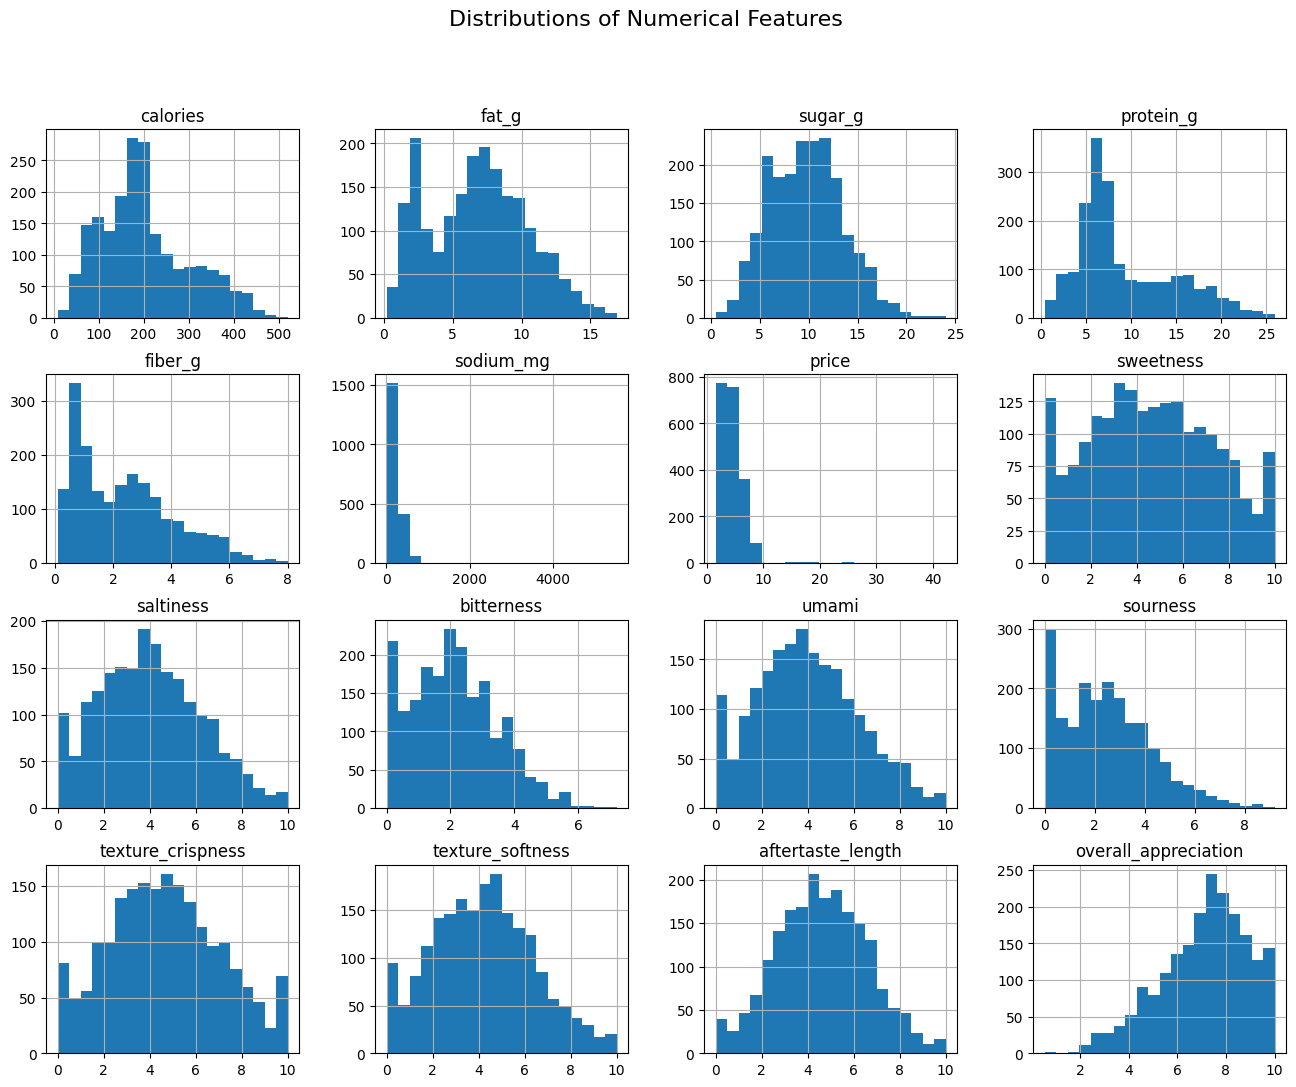

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['calories', 'fat_g', 'sugar_g', 'protein_g',
                'fiber_g', 'sodium_mg', 'price',
                'sweetness', 'saltiness', 'bitterness',
                'umami', 'sourness', 'texture_crispness',
                'texture_softness', 'aftertaste_length',
                'overall_appreciation']

df[numerical_cols].hist(figsize=(16, 12), bins=20)
plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.show()


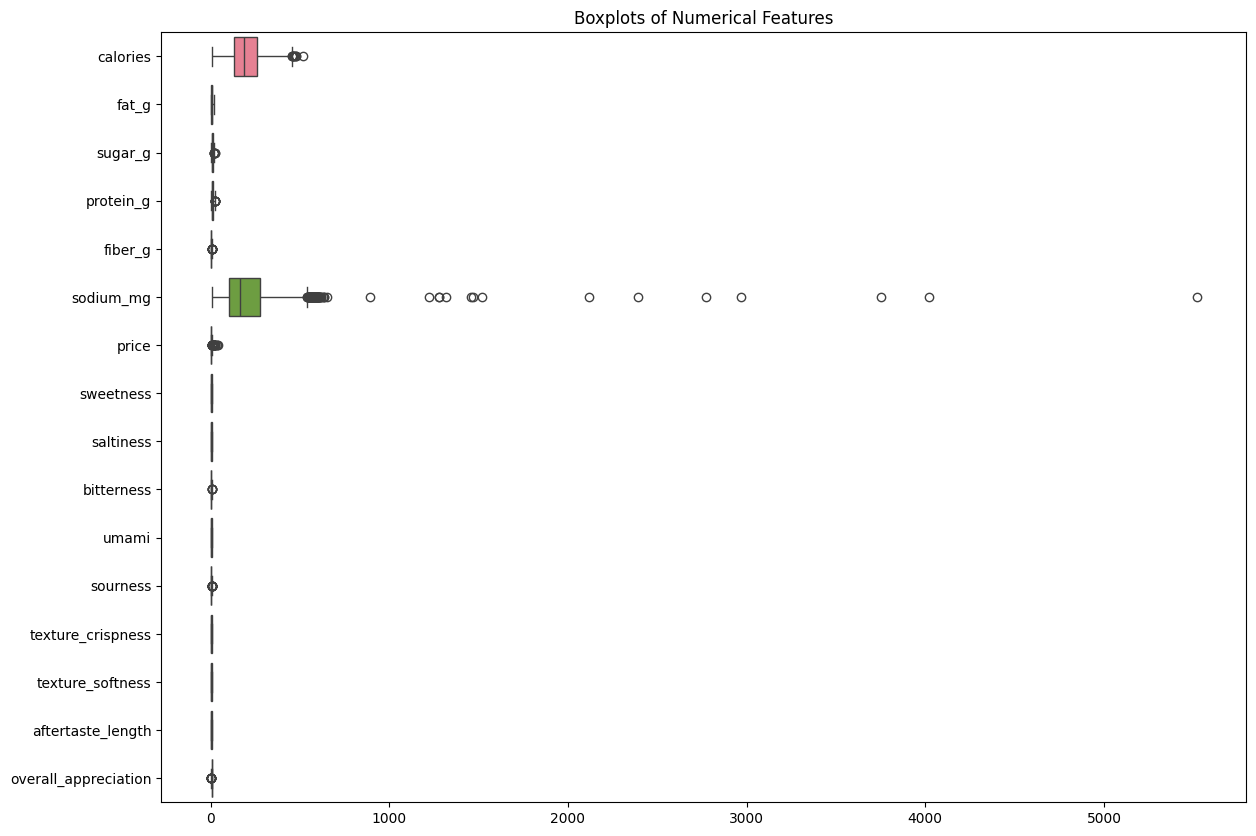

In [43]:
plt.figure(figsize=(14, 10))
sns.boxplot(data=df[numerical_cols], orient="h")
plt.title("Boxplots of Numerical Features")
plt.show()


The histograms and boxplots together show a clear picture of how the numerical features behave. Most nutritional variables (calories, fat, sugar, protein, fiber) are **right-skewed**, meaning most products have moderate values while a smaller group shows much higher amounts. Sensory attributes follow smoother, mostly unimodal distributions, with bitterness and sourness rated lower on average. Texture-related variables also display stable mid-range patterns.

The boxplots confirm these observations and reveal **strong outliers** in a few variables, especially **sodium_mg** and **price**, which contain extreme high values far from the rest of the data. These long right tails may affect scaling and some models later. Sensory features and the target **overall_appreciation** show compact, well-behaved distributions with no major outliers, which makes them more predictable for machine learning.

Overall, sensory variables behave consistently and are likely reliable predictors, while some nutritional and price features will require careful treatment due to skewness and outliers.


### 2.3 Target Analysis

In this step we focus on the two targets of the project:
- `overall_appreciation` (regression)
- `success` (classification)

The goal is to understand their distributions and check for class imbalance.

#### 2.3.1 `overall_appreciation `

In [44]:
df["overall_appreciation"].describe()

,overall_appreciation
count,2000.000000
mean,7.092942
std,1.784600
min,0.548065
25%,5.982634
50%,7.320900
75%,8.402952
max,10.000000


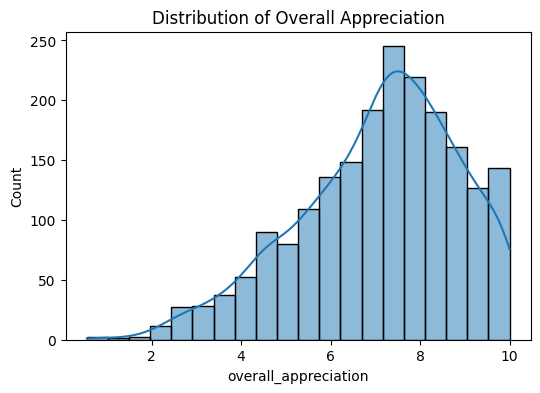

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["overall_appreciation"], bins=20, kde=True)
plt.title("Distribution of Overall Appreciation")
plt.xlabel("overall_appreciation")
plt.ylabel("Count")
plt.show()


The distribution of overall_appreciation is clearly left-skewed, indicating a strong bias toward positive sensory ratings. The data is heavily concentrated in the 7 to 9 range, with a median score of approximately 7.3. Notably, 75% of products scored above 6.0, while ratings below 4 are rare.

This imbalance means the regression model will be trained primarily on high-scoring products. Consequently, it may achieve high accuracy for popular items but struggle to generalize or accurately predict lower appreciation scores due to the scarcity of negative examples.


#### 2.3.2 `success`

In [46]:
# Absolute and relative frequency of each class
class_counts = df["success"].value_counts()
class_percent = df["success"].value_counts(normalize=True) * 100

class_counts, class_percent

(success
 1    1875
 0     125
 Name: count, dtype: int64,
 success
 1    93.75
 0     6.25
 Name: proportion, dtype: float64)

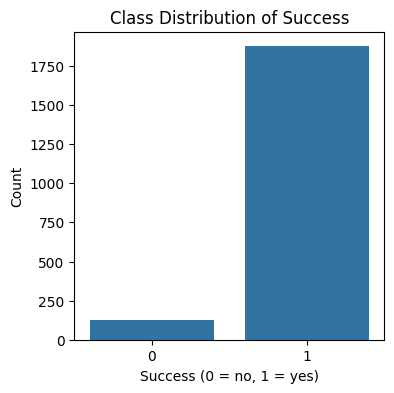

In [47]:
plt.figure(figsize=(4,4))
sns.countplot(x="success", data=df)
plt.title("Class Distribution of Success")
plt.xlabel("Success (0 = no, 1 = yes)")
plt.ylabel("Count")
plt.show()


We observe a severe class imbalance in the success variable. Positive outcomes (Class 1) overwhelmingly dominate the dataset, accounting for 93.75% (1,875 samples), while negative outcomes (Class 0) represent only 6.25% (125 samples).

This disparity presents a significant challenge. A naive model could achieve ~94% accuracy simply by predicting "Success" for every instance, failing to detect any failures. Consequently, we cannot rely on raw accuracy; we must prioritize metrics like Precision, Recall, and F1-Score to properly evaluate performance on the minority class.

To address this imbalance and improve the model's ability to learn the minority class, we will employ SMOTENC (Synthetic Minority Over-sampling Technique for Nominal and Continuous) during the preprocessing stage.


### 2.4 Bivariate Analysis

Here we explore how features relate to each other and to the two targets.  
We begin with correlation matrices, then look at bivariate relationships for numerical variables using simple regression trendlines and analyze categorical variables with Chi-test.


#### 2.4.1 Correlation Matrix

In [48]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number]).copy()

corr_matrix = numeric_df.corr()
corr_matrix

,calories,fat_g,sugar_g,protein_g,fiber_g,sodium_mg,spicy_level,color_intensity,aroma_intensity,sweetness,...,brand_trust,packaging_appeal,eco_score,shelf_life_days,distribution_channels_count,review_count_prelaunch,allergy_warnings_count,marketing_spend_k,overall_appreciation,success
calories,1.000000,0.751651,-0.307914,0.660662,0.755742,0.506487,0.082713,0.004983,0.028935,-0.044630,...,0.007001,-0.028390,-0.041885,0.025330,-0.005603,0.004587,0.120546,-0.053722,-0.529062,-0.090886
fat_g,0.751651,1.000000,-0.193571,0.423710,0.695243,0.483219,0.080036,0.027038,0.058768,0.065515,...,-0.011361,-0.032071,-0.024808,0.034008,0.015720,0.005979,0.129714,-0.050300,-0.415322,-0.034417
sugar_g,-0.307914,-0.193571,1.000000,-0.439015,-0.357001,-0.260572,-0.077422,0.077860,0.029167,0.261348,...,0.038811,0.029170,0.007250,-0.292221,0.014322,0.002213,0.073977,-0.006604,0.393671,0.102138
protein_g,0.660662,0.423710,-0.439015,1.000000,0.476991,0.417716,0.050003,-0.074641,-0.008386,-0.168127,...,-0.018481,-0.001428,-0.049630,-0.062743,-0.034192,0.021879,0.081105,-0.051049,-0.466634,-0.118078
fiber_g,0.755742,0.695243,-0.357001,0.476991,1.000000,0.483495,0.079969,-0.040751,0.031830,-0.088194,...,0.000935,-0.013345,0.005684,0.361268,0.009116,-0.009740,0.026568,-0.023636,-0.492515,-0.069267
sodium_mg,0.506487,0.483219,-0.260572,0.417716,0.483495,1.000000,0.053734,0.059238,0.000815,-0.065830,...,-0.019269,-0.037447,-0.012017,0.073105,-0.005640,-0.006887,0.043560,-0.026489,-0.423338,-0.079921
spicy_level,0.082713,0.080036,-0.077422,0.050003,0.079969,0.053734,1.000000,-0.000837,-0.009315,-0.020790,...,0.030347,-0.010927,0.018513,0.059951,-0.015120,-0.018378,0.004704,-0.032034,-0.087699,-0.007981
color_intensity,0.004983,0.027038,0.077860,-0.074641,-0.040751,0.059238,-0.000837,1.000000,0.036073,0.049926,...,-0.020968,-0.018108,0.003450,-0.100287,-0.011812,0.012658,0.055783,0.010362,0.023265,-0.030422
aroma_intensity,0.028935,0.058768,0.029167,-0.008386,0.031830,0.000815,-0.009315,0.036073,1.000000,0.029488,...,0.032332,-0.025759,0.001977,0.014203,0.010650,-0.030268,0.000491,0.024751,0.245488,0.078433
sweetness,-0.044630,0.065515,0.261348,-0.168127,-0.088194,-0.065830,-0.020790,0.049926,0.029488,1.000000,...,-0.017226,-0.044119,0.005884,-0.352344,0.012710,0.015497,0.153430,0.013202,0.353900,0.057735


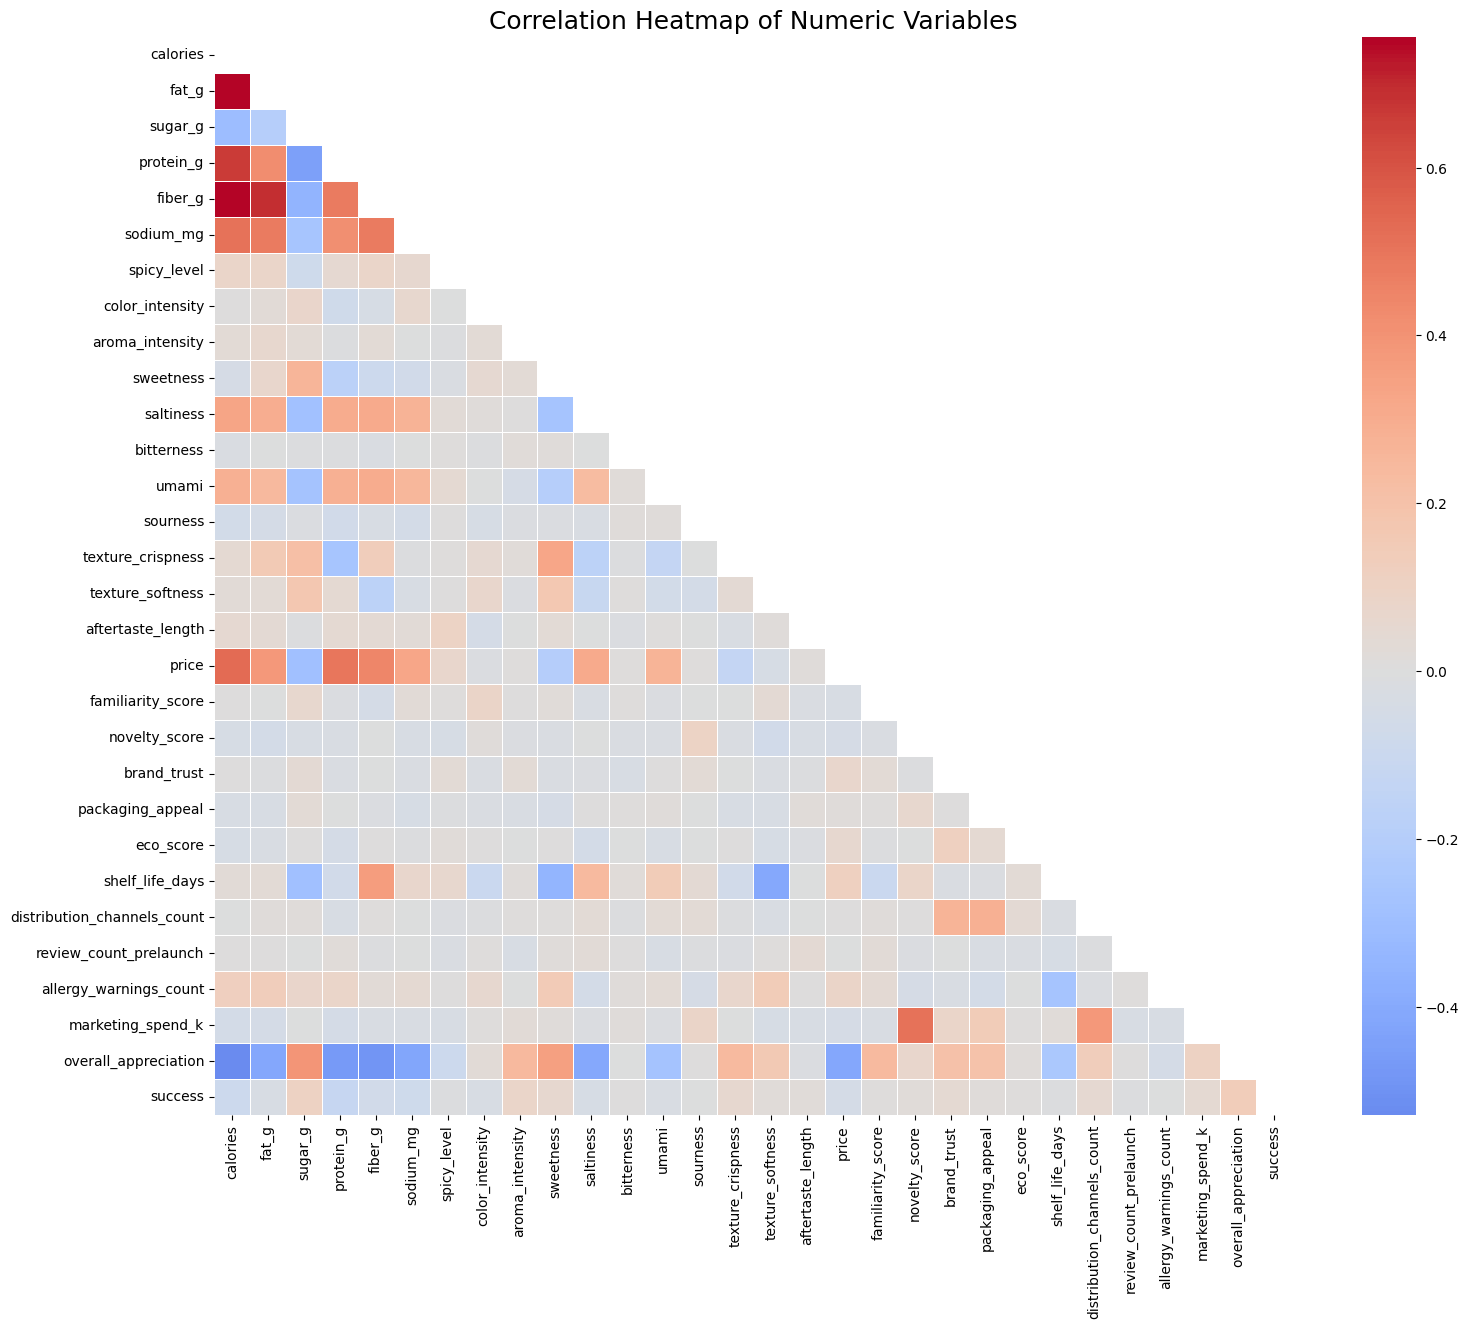

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(18, 14))

# mask upper triangle for readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False,      # turn to True if you want the numbers
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numeric Variables", fontsize=18)
plt.show()

All correlations between success and the numeric features are extremely small (|r| < 0.12). Even its correlation with overall_appreciation is only 0.14, which is weak.

This indicates that market success does not have any strong linear relationship with any individual numeric feature. Therefore, linear correlation is not sufficient to understand or predict market success. Non-linear models (tree-based methods, ensembles, neural networks) will likely be required to capture more complex interactions and patterns.


In [50]:
corr_overall = corr_matrix["overall_appreciation"].sort_values(ascending=False)
corr_success = corr_matrix["success"].sort_values(ascending=False)

corr_overall, corr_success

(overall_appreciation           1.000000
 sugar_g                        0.393671
 sweetness                      0.353900
 aroma_intensity                0.245488
 familiarity_score              0.242011
 texture_crispness              0.234477
 brand_trust                    0.198984
 packaging_appeal               0.194647
 texture_softness               0.159948
 success                        0.137208
 distribution_channels_count    0.129046
 marketing_spend_k              0.098867
 novelty_score                  0.069333
 color_intensity                0.023265
 eco_score                      0.016054
 sourness                       0.006250
 review_count_prelaunch         0.004584
 bitterness                    -0.002624
 aftertaste_length             -0.015868
 allergy_warnings_count        -0.050845
 spicy_level                   -0.087699
 shelf_life_days               -0.245475
 umami                         -0.269377
 saltiness                     -0.407257
 fat_g          

/tmp/ipython-input-3597463327.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


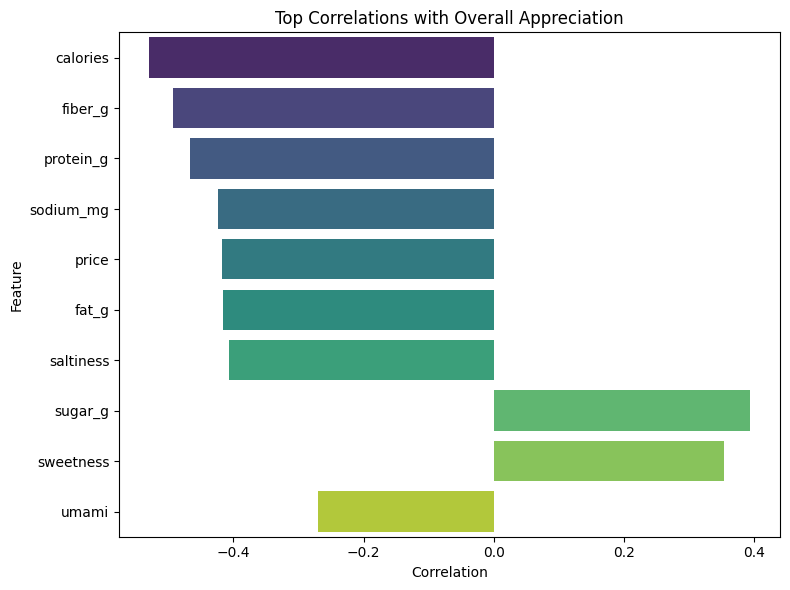

In [51]:

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr = df[numerical_cols].corr()

# Strongest correlations with overall_appreciation (excluding itself)
corr_overall = (
    corr["overall_appreciation"]
    .drop("overall_appreciation")
    .sort_values(key=abs, ascending=False)
)

top_n = 10

plt.figure(figsize=(8, 6))
sns.barplot(
    x=corr_overall[:top_n].values,
    y=corr_overall[:top_n].index,
    palette="viridis"
)
plt.title("Top Correlations with Overall Appreciation")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


/tmp/ipython-input-4009314758.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


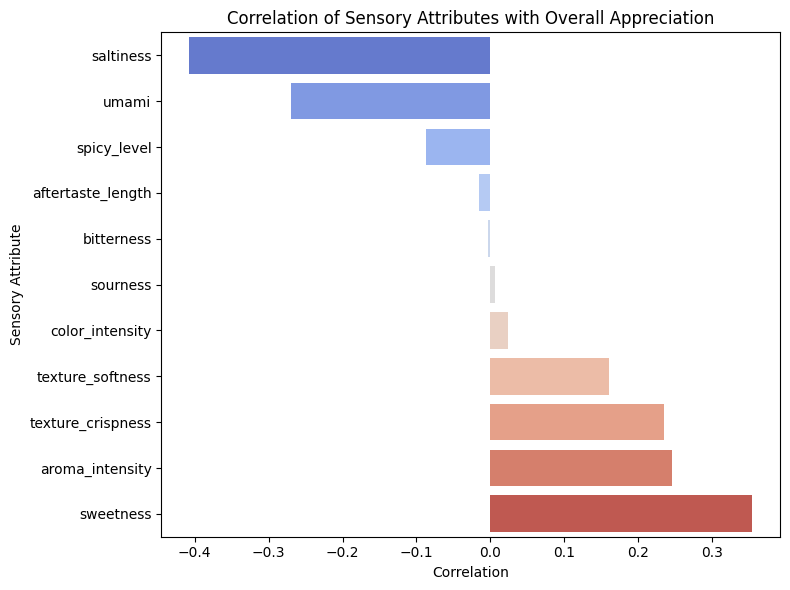

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure success is numeric
df["success"] = df["success"].astype(int)

# List of sensory attributes
sensory_features = [
    'spicy_level',
    'color_intensity',
    'aroma_intensity',
    'sweetness',
    'saltiness',
    'bitterness',
    'umami',
    'sourness',
    'texture_crispness',
    'texture_softness',
    'aftertaste_length'
]

# Compute correlations with overall_appreciation
sensory_corr = df[sensory_features + ["overall_appreciation"]].corr()["overall_appreciation"].drop("overall_appreciation")

# Sort by correlation strength
sensory_corr_sorted = sensory_corr.sort_values(ascending=True)  # lowest to highest

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x=sensory_corr_sorted.values,
    y=sensory_corr_sorted.index,
    palette="coolwarm"
)
plt.title("Correlation of Sensory Attributes with Overall Appreciation")
plt.xlabel("Correlation")
plt.ylabel("Sensory Attribute")
plt.tight_layout()
plt.show()


The bivariate analysis shows that several sensory attributes have a clear positive relationship with `overall_appreciation`. In particular, `sweetness` (0.35), `aroma_intensity` (0.25), `texture_crispness` (0.23), and `texture_softness` (0.16) display upward trends and moderate positive correlations, indicating that products scoring higher on these sensory dimensions tend to receive better appreciation ratings. Other sensory features such as bitterness (-0.00), sourness (0.01), umami (-0.27), spicy_level (-0.09), color_intensity (0.02), and aftertaste_length (-0.02) show little to no linear association.

Nutritional variables reinforce this trend: `sugar_g` (0.39) correlates positively with appreciation, while heavier nutritional components like `calories `(-0.53), `protein_g` (-0.47), `fiber_g` (-0.49), and `sodium_mg` (-0.42) correlate negatively.

For `success`, all correlations remain weak. Sensory attributes contribute almost no linear signal, and even appreciation itself shows only a modest correlation. This suggests that while sensory features help explain how much consumers *like* a product, they do not directly predict whether it becomes commercially successful.


#### 2.4.2 Categorical Features vs Success (Chi-Square Test)

To understand whether each categorical variable is statistically associated with the target **success**, we run a Chi-Square independence test. A low p-value (typically < 0.05) indicates that the feature and the target are *not independent*, meaning the category distribution differs between successful and unsuccessful products.


In [53]:
from scipy.stats import chi2_contingency
import pandas as pd

categorical_vars = [
    'category', 'subcategory', 'country_origin',
    'organic', 'gluten_free', 'contains_nuts',
    'contains_meat', 'contains_dairy', 'seasonal'
]

rows = []

for col in categorical_vars:
    table = pd.crosstab(df[col], df['success'])
    chi2, p, dof, expected = chi2_contingency(table)
    rows.append({
        "variable": col,
        "chi2": chi2,
        "p_value": p
    })

chi2_df = (
    pd.DataFrame(rows)
    .sort_values("p_value")
    .assign(significant_0_05=lambda d: d["p_value"] < 0.05)
)

chi2_df


,variable,chi2,p_value,significant_0_05
0,category,41.751044,0.000002,True
1,subcategory,61.234239,0.009840,True
2,country_origin,35.739713,0.011360,True
3,organic,1.550174,0.213110,False
5,contains_nuts,1.331962,0.248456,False
4,gluten_free,0.557093,0.455434,False
8,seasonal,0.504390,0.477577,False
6,contains_meat,0.414083,0.519905,False
7,contains_dairy,0.052136,0.819388,False


The Chi-Square results show that only **category**, **subcategory**, and **country_origin** have significant associations with success (p < 0.05). This means success rates differ across these groups. All other categorical features show high p-values, indicating no meaningful relationship with success in this dataset.


In [54]:
success_rates = df.groupby("category")["success"].mean().sort_values(ascending=False)
success_rates

,success
category,
Supplements,1.000000
RTD Meal,1.000000
Condiment,0.980000
Snacks,0.967391
Frozen,0.958333
Bakery,0.949239
Dairy,0.944625
Beverage,0.933504
Ready Meal,0.871391


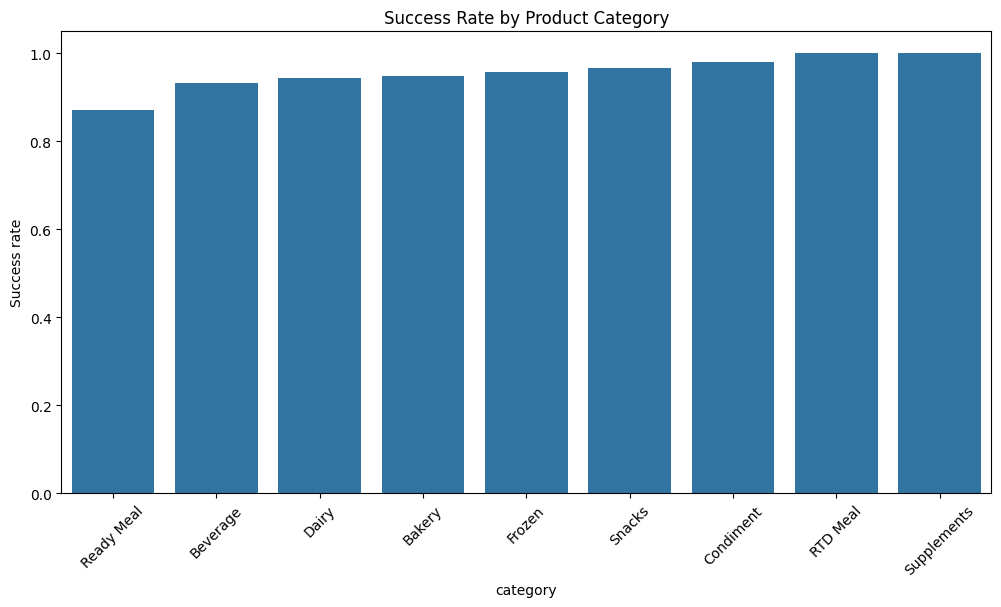

In [55]:
success_rate = df.groupby('category')['success'].mean().sort_values()

plt.figure(figsize=(12,6))
sns.barplot(x=success_rate.index, y=success_rate.values)
plt.xticks(rotation=45)
plt.ylabel("Success rate")
plt.title("Success Rate by Product Category")
plt.show()


The barplot indicates that all product categories have high success rates
(approximately 87% to 100%). Although the Chi-square test detected a statistically
significant association between `category` and `success`, the practical differences
between categories are relatively small. This means that while category membership
does influence success rates, it does not strongly separate successful from
unsuccessful products on its own.

This supports the earlier conclusion that market success has weak simple
relationships and likely depends on more complex interactions captured only
by non-linear models.

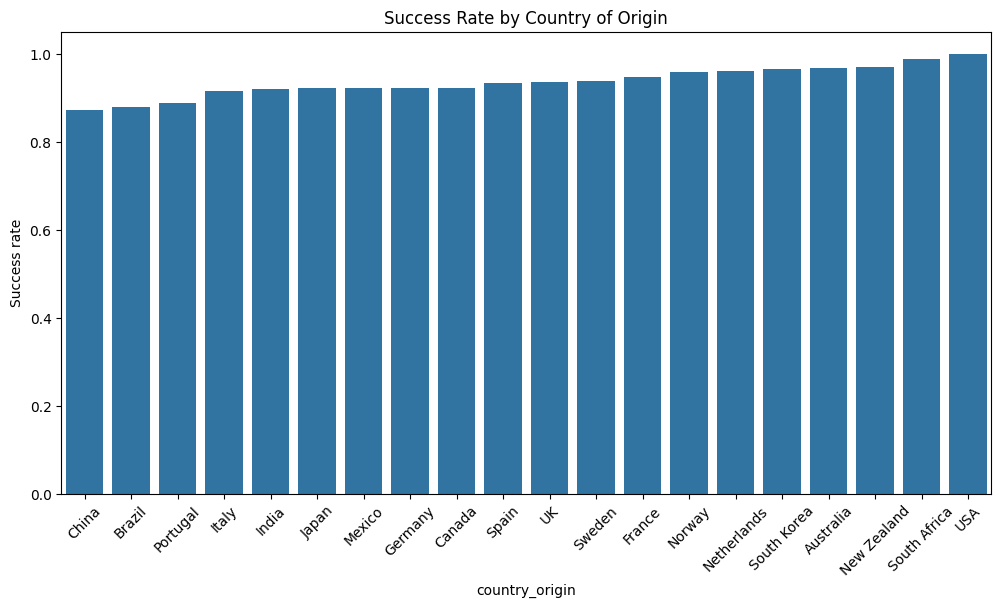

In [56]:
success_country = df.groupby('country_origin')['success'].mean().sort_values()

plt.figure(figsize=(12,6))
sns.barplot(x=success_country.index, y=success_country.values)
plt.xticks(rotation=45)
plt.ylabel("Success rate")
plt.title("Success Rate by Country of Origin")
plt.show()


Success rates differ across countries of origin, which matches the significant
Chi-square test. This indicates that origin may influence consumer perception or
market positioning.


##3. Data Preparation

### 3.1 Train / Validation / Test Split

The assignment requires a fixed split based on row order:

- First **1600 rows** → training set  
- Next **200 rows** → validation set  
- Last **200 rows** → test set  



In [57]:
train_raw = df.iloc[:1600].copy()
val_raw = df.iloc[1600:1800].copy()
test_raw = df.iloc[1800:2000].copy()

# Define Targets and Identifiers to Drop
target_cols = ['overall_appreciation', 'success']
id_cols = ['product_id', 'name', 'description']

# Separate X and y
X_train = train_raw.drop(columns=target_cols + id_cols)
y_train_class = train_raw['success']
y_train_reg = train_raw['overall_appreciation']

X_val = val_raw.drop(columns=target_cols + id_cols)
y_val_class = val_raw['success']
y_val_reg = val_raw['overall_appreciation']

X_test = test_raw.drop(columns=target_cols + id_cols)
y_test_class = test_raw['success']
y_test_reg = test_raw['overall_appreciation']

### 3.2 Handling Outliers, Missing Values & Encoding


In [58]:
# Re-initialize X_train, y_train_class, and y_train_reg from the raw data to ensure aligned indices
X_train = train_raw.drop(columns=target_cols + id_cols)
y_train_class = train_raw['success']
y_train_reg = train_raw['overall_appreciation']

# 1. Identify columns with outliers (from your Data Understanding)
outlier_cols = ['sodium_mg', 'price', 'marketing_spend_k']

# 2. Calculate thresholds (IQR Method)
Q1 = X_train[outlier_cols].quantile(0.25)
Q3 = X_train[outlier_cols].quantile(0.75)
IQR = Q3 - Q1

# Using multiplier 3.0 removes only "Extreme" outliers (safer than 1.5)
lower_bound = Q1 - 3.0 * IQR
upper_bound = Q3 + 3.0 * IQR

# 3. Create a mask of valid rows
# Rows are kept if they are NOT outliers in ANY of the specified columns
mask = ~((X_train[outlier_cols] < lower_bound) | (X_train[outlier_cols] > upper_bound)).any(axis=1)

# 4. Apply filter to Features and Targets
print(f"Original Train shape: {X_train.shape}")

X_train = X_train[mask]
y_train_class = y_train_class[mask]
y_train_reg = y_train_reg[mask]

print(f"Cleaned Train shape: {X_train.shape}")
print(f"Dropped {mask.shape[0] - X_train.shape[0]} outlier rows.")

Original Train shape: (1600, 37)
Cleaned Train shape: (1570, 37)
Dropped 30 outlier rows.


In [59]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# Define column groups
# numeric_features: all float/int columns except binary booleans
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# categorical_features: objects/categories
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# binary_features: bools (already 0/1 or True/False)
binary_features = X_train.select_dtypes(include=['bool']).columns.tolist()

# Create Transformers
# 1. Numeric: Impute missing (Median is robust to outliers like sodium_mg) + Scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# 2. Categorical: Impute missing (Constant) + OneHotEncode
# handle_unknown='ignore' is crucial if Val/Test have categories not in Train
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Binary: Just impute (rare, but safe)
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine into a Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', binary_transformer, binary_features)
    ])

###3.3 Apply Transformations

In [60]:
# First, get the list of boolean columns from X_train
# This list is used to convert the columns across all dataframes
binary_columns_present = X_train.select_dtypes(include=['bool']).columns.tolist()

# Convert these boolean columns to integer (0 or 1) in all datasets
for col in binary_columns_present:
    X_train[col] = X_train[col].astype(int)
    X_val[col] = X_val[col].astype(int)
    X_test[col] = X_test[col].astype(int)

# Fit ONLY on Train, Transform on all
# This ensures no data leakage (a key evaluation criteria)
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Get feature names back for readability/feature selection later
# Call get_feature_names_out on the full preprocessor to get all transformed feature names
feature_names = preprocessor.get_feature_names_out().tolist()

# Convert back to DataFrame (Optional, but helpful for analysis)
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_val_df = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print("Data Preparation Complete.")
print(f"Train shape: {X_train_df.shape}")
print(f"Validation shape: {X_val_df.shape}")
print(f"Test shape: {X_test_df.shape}")

Data Preparation Complete.
Train shape: (1570, 97)
Validation shape: (200, 97)
Test shape: (200, 97)


### 3.4 Feature Selection

####3.4.1 Statistical Feature Filtering

We performed statistical cleaning to remove noise and redundancy. Specifically, we used **Variance Threshold** to drop constant columns, **Correlation Analysis** to eliminate highly correlated duplicates, and the **Chi-Squared Test** to identify and discard categorical variables that statistically have no significant relationship with the target.

In [61]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2

# A. Variance Threshold (Remove constants)
var_selector = VarianceThreshold(threshold=0)
var_selector.fit(X_train_df)
cols_variance_keep = X_train_df.columns[var_selector.get_support()]

# B. Correlation Filter (Remove highly correlated > 0.95)
# We use the columns kept by variance filter
corr_matrix = X_train_df[cols_variance_keep].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Dropped by Correlation (>0.95): {to_drop_corr}")

# C. Chi-Squared Test (Only for Categorical/Binary Columns)
# Identify binary columns (values are only 0 or 1) to avoid negative Scaled values
binary_cols = [c for c in cols_variance_keep if X_train_df[c].isin([0, 1]).all()]

# Run Chi-Squared to find features with p-value > 0.05 (Not significant)
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_train_df[binary_cols], y_train_class)
chi2_pvalues = pd.Series(chi2_selector.pvalues_, index=binary_cols)
to_drop_chi2 = chi2_pvalues[chi2_pvalues > 0.05].index.tolist()

print(f"Dropped by Chi-Squared (p>0.05): {len(to_drop_chi2)} columns")

# D. Define the 'Clean' set (Variance + Correlation + Chi-Squared filtered)
# We exclude features dropped by ANY of the 3 methods
to_drop_all = set(to_drop_corr + to_drop_chi2)
features_clean = [c for c in cols_variance_keep if c not in to_drop_all]

print(f"Final Clean Feature Count: {len(features_clean)}")

Dropped by Correlation (>0.95): []
Dropped by Chi-Squared (p>0.05): 62 columns
Final Clean Feature Count: 35


#### 3.4.2 Model-Based Feature Selection

We structured our experiments around three distinct feature sets: features_all as a baseline, features_no_sensory to explicitly test if expensive tasting panels can be replaced (the core business question), and features_technical, which combines **Recursive Feature Elimination (RFE) and Ensemble methods** to mathematically select the most predictive features for maximum accuracy.

In [62]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# SET 1: All Features (Baseline)
features_all = features_clean

# SET 2: No Sensory (Business Question)
# Filter out columns containing sensory keywords
sensory_keywords = ['spicy_level',
    'color_intensity',
    'aroma_intensity',
    'sweetness',
    'saltiness',
    'bitterness',
    'umami',
    'sourness',
    'texture_crispness',
    'texture_softness',
    'aftertaste_length']
features_no_sensory = [c for c in features_clean if not any(s in c for s in sensory_keywords)]

# SET 3: Best Technical (Wrapper & Ensemble)
# We use the 'features_clean' as the starting point to avoid multicollinearity issues
print("Running RFE and Ensemble selection...")

# 3.1 Wrapper Method (RFE)
rfe = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=15)
rfe.fit(X_train_df[features_clean], y_train_class)
selected_rfe = X_train_df[features_clean].columns[rfe.support_].tolist()

# 3.2 Ensemble Method (Feature Importance)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_df[features_clean], y_train_class)
importances = pd.Series(rf.feature_importances_, index=features_clean)
selected_ensemble = importances.sort_values(ascending=False).head(15).index.tolist()

# Combine them (Union of top features from both methods)
features_technical = list(set(selected_rfe + selected_ensemble))

print("\n--- Feature Sets Defined ---")
print(f"1. All Features: {len(features_all)} columns")
print(f"2. No Sensory: {len(features_no_sensory)} columns (Cheaper)")
print(f"3. Technical Best: {len(features_technical)} columns (Optimized)")
print(f"   Tech Features: {features_technical}")

Running RFE and Ensemble selection...

--- Feature Sets Defined ---
1. All Features: 35 columns
2. No Sensory: 24 columns (Cheaper)
3. Technical Best: 16 columns (Optimized)
   Tech Features: ['num__fat_g', 'num__familiarity_score', 'num__sodium_mg', 'num__color_intensity', 'num__marketing_spend_k', 'num__fiber_g', 'num__calories', 'num__sourness', 'num__texture_softness', 'num__protein_g', 'num__price', 'num__sugar_g', 'num__novelty_score', 'num__aftertaste_length', 'num__brand_trust', 'num__saltiness']


###3.5 Handling Class Imbalance (SMOTENC)

We addressed the imbalance in the target success by generating a balanced training set using SMOTENC, a technique designed for mixed numerical and categorical data. This method synthesizes new minority-class examples while respecting categorical constraints, providing a robust X_train_bal to compare against standard imbalanced data in our modeling.

--- 3.6 Creating Balanced Training Set ---
Original Train shape: (1570, 97) | Class Dist: {1: 1476, 0: 94}
Balanced Train shape: (2952, 97) | Class Dist: {0: 1476, 1: 1476}


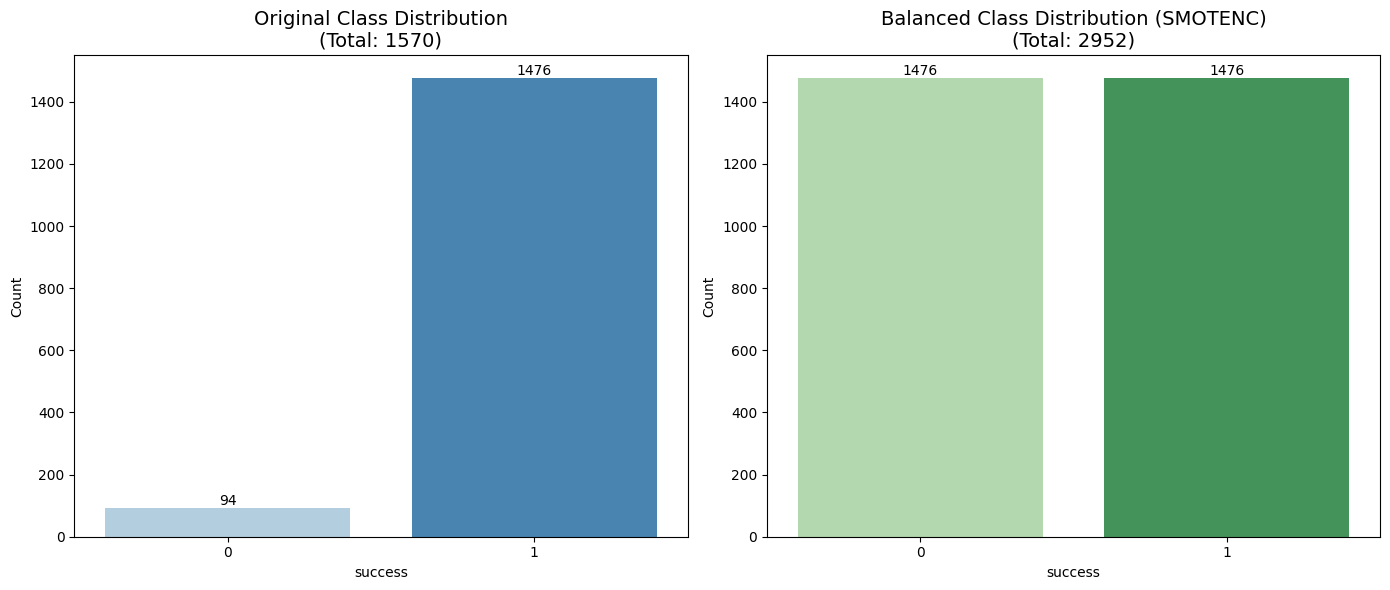

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTENC

print("--- 3.6 Creating Balanced Training Set ---")

# 1. Identify Categorical/Binary Columns
# Since we One-Hot Encoded, these are columns with only 2 unique values (0 and 1)
cat_indices = [i for i, col in enumerate(X_train_df.columns) if X_train_df[col].nunique() <= 2]

# 2. Apply SMOTENC to Create a BALANCED Version of Train
# Note: We ONLY resample the Training data. Validation and Test must remain real.
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42, sampling_strategy='auto')

X_train_bal, y_train_bal = smote_nc.fit_resample(X_train_df, y_train_class)

# --- Print Statistics ---
print(f"Original Train shape: {X_train_df.shape} | Class Dist: {y_train_class.value_counts().to_dict()}")
print(f"Balanced Train shape: {X_train_bal.shape} | Class Dist: {y_train_bal.value_counts().to_dict()}")

# --- 3. VISUALIZATION SECTION ---
def plot_resampling_results(y_original, y_resampled):
    """Helper function to plot side-by-side count plots."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Original Distribution
    sns.countplot(x=y_original, ax=axes[0], palette='Blues', hue=y_original, legend=False)
    axes[0].set_title(f"Original Class Distribution\n(Total: {len(y_original)})", fontsize=14)
    axes[0].set_ylabel("Count")

    # Add count labels on top of bars
    for container in axes[0].containers:
        axes[0].bar_label(container)

    # Plot 2: Balanced Distribution
    sns.countplot(x=y_resampled, ax=axes[1], palette='Greens', hue=y_resampled, legend=False)
    axes[1].set_title(f"Balanced Class Distribution (SMOTENC)\n(Total: {len(y_resampled)})", fontsize=14)
    axes[1].set_ylabel("Count")

    # Add count labels on top of bars
    for container in axes[1].containers:
        axes[1].bar_label(container)

    plt.tight_layout()
    plt.show()

# Run the visualization
plot_resampling_results(y_train_class, y_train_bal)

##4. Modeling

### 4.1 Classification (`sucess`)

####4.1.1 Stabilishing baselines

In [64]:
import pandas as pd
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, accuracy_score, average_precision_score

# 1. Define Baseline Models
# Logistic Regression: Added class_weight='balanced' for the imbalanced run
baseline_models = {
    "Dummy (Most Frequent)": DummyClassifier(strategy='most_frequent'),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
}

baseline_results = []

print("--- Phase 2: Running Baselines ---")

# A. Run on Imbalanced (Raw) Training Data
print("Evaluating Baselines on Imbalanced Data...")
for name, model in baseline_models.items():
    model.fit(X_train_df, y_train_class)
    y_pred = model.predict(X_val_df)

    baseline_results.append({
        "Strategy": "Imbalanced (Baseline)",
        "Model": name,
        "Recall (Failures)": recall_score(y_val_class, y_pred, pos_label=0),
        "F1 (Failures)": f1_score(y_val_class, y_pred, pos_label=0),
        "Accuracy": accuracy_score(y_val_class, y_pred)
    })

# B. Run on Balanced (SMOTE) Training Data
print("Evaluating Baselines on SMOTE Balanced Data...")
for name, model in baseline_models.items():
    if "Dummy" in name: continue # Skip Dummy for SMOTE

    # Create clean instance (remove class_weight since data is balanced)
    clean_model = LogisticRegression(max_iter=1000, random_state=42)
    clean_model.fit(X_train_bal, y_train_bal)
    y_pred = clean_model.predict(X_val_df)

    baseline_results.append({
        "Strategy": "Balanced (SMOTE)",
        "Model": name,
        "Recall (Failures)": recall_score(y_val_class, y_pred, pos_label=0),
        "F1 (Failures)": f1_score(y_val_class, y_pred, pos_label=0),
        "Accuracy": accuracy_score(y_val_class, y_pred)
    })

# Display
df_baselines = pd.DataFrame(baseline_results)
display(df_baselines)

--- Phase 2: Running Baselines ---
Evaluating Baselines on Imbalanced Data...
Evaluating Baselines on SMOTE Balanced Data...


,Strategy,Model,Recall (Failures),F1 (Failures),Accuracy
0,Imbalanced (Baseline),Dummy (Most Frequent),0.000000,0.000000,0.910
1,Imbalanced (Baseline),Logistic Regression,0.388889,0.177215,0.675
2,Balanced (SMOTE),Logistic Regression,0.055556,0.090909,0.900


The baseline evaluation effectively exposes the "accuracy trap" inherent in this imbalanced dataset, where the Dummy Classifier achieved 91% accuracy simply by ignoring all failures (Recall 0.0). This result serves as a critical warning that high accuracy scores are meaningless without a corresponding ability to detect the minority class. Furthermore, the inability of Logistic Regression to find a stable decision boundary, regardless of whether it was trained on raw or SMOTE-balanced data, indicates that "Success" and "Failure" are not linearly separable. The linear model either generated excessive false alarms to catch failures or reverted to the majority baseline, confirming that effective detection requires the non-linear capabilities of the advanced tree ensemble models we will test next.

####4.1.2 Model Screening

In [65]:
!pip install catboost

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 1. Define Screening Models
# Note: For tree models in "Imbalanced" mode, we force class_weight='balanced'
screening_models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "SVM": SVC(class_weight='balanced', probability=True, random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=15, eval_metric='logloss', random_state=42), # 15 ~= 94/6 ratio
    "LightGBM": LGBMClassifier(class_weight='balanced', verbose=-1, random_state=42),
    "CatBoost": CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=42)
}

# 2. Define Feature Sets (Referencing your previous code)
feature_sets = {
    "All Features": features_all,
    "No Sensory": features_no_sensory,
    "Technical Best": features_technical
}

screening_results = []

print("--- Phase 3: Running Model Screening ---")

for feat_name, feats in feature_sets.items():
    print(f"Processing Feature Set: {feat_name}...")

    # --- Strategy A: Imbalanced (Class Weights) ---
    for name, model in screening_models.items():
        model.fit(X_train_df[feats], y_train_class)
        y_pred = model.predict(X_val_df[feats])

        # Get Probabilities for PR-AUC
        try:
            y_prob_0 = 1 - model.predict_proba(X_val_df[feats])[:, 1]
        except:
            y_prob_0 = np.zeros(len(y_pred))

        screening_results.append({
            "Strategy": "Imbalanced",
            "Set": feat_name,
            "Model": name,
            "Recall (0)": recall_score(y_val_class, y_pred, pos_label=0),
            "F1 (0)": f1_score(y_val_class, y_pred, pos_label=0),
            "PR-AUC (0)": average_precision_score(y_val_class, y_prob_0, pos_label=0),
            "Accuracy": accuracy_score(y_val_class, y_pred)
        })

    # --- Strategy B: Balanced (SMOTE) ---
    for name, model in screening_models.items():
        # Important: For SMOTE, we must NOT use class_weights (Double Penalty)
        # We re-instantiate clean models for the SMOTE run
        if name == "XGBoost":
            clean_model = XGBClassifier(eval_metric='logloss', random_state=42)
        elif name == "LightGBM":
            clean_model = LGBMClassifier(verbose=-1, random_state=42)
        elif name == "CatBoost":
            clean_model = CatBoostClassifier(verbose=0, random_state=42)
        elif name == "Random Forest":
            clean_model = RandomForestClassifier(random_state=42)
        elif name == "Decision Tree":
            clean_model = DecisionTreeClassifier(random_state=42)
        elif name == "SVM":
            clean_model = SVC(probability=True, random_state=42)
        else:
            clean_model = model # KNN / NB don't have class_weight params anyway

        clean_model.fit(X_train_bal[feats], y_train_bal)
        y_pred = clean_model.predict(X_val_df[feats])

        try:
            y_prob_0 = 1 - clean_model.predict_proba(X_val_df[feats])[:, 1]
        except:
            y_prob_0 = np.zeros(len(y_pred))

        screening_results.append({
            "Strategy": "Balanced (SMOTE)",
            "Set": feat_name,
            "Model": name,
            "Recall (0)": recall_score(y_val_class, y_pred, pos_label=0),
            "F1 (0)": f1_score(y_val_class, y_pred, pos_label=0),
            "PR-AUC (0)": average_precision_score(y_val_class, y_prob_0, pos_label=0),
            "Accuracy": accuracy_score(y_val_class, y_pred)
        })

# 3. Output & Visualization
df_screening = pd.DataFrame(screening_results)

# Show Top 10 Winners
print("\nTop 10 Models (Sorted by F1-Score of Failures):")
display(df_screening.sort_values(by=["F1 (0)", "Recall (0)"], ascending=False).head(10))



--- Phase 3: Running Model Screening ---
Processing Feature Set: All Features...
Processing Feature Set: No Sensory...
Processing Feature Set: Technical Best...

Top 10 Models (Sorted by F1-Score of Failures):


,Strategy,Set,Model,Recall (0),F1 (0),PR-AUC (0),Accuracy
1,Imbalanced,All Features,Naive Bayes,0.944444,0.200000,0.125402,0.320
17,Imbalanced,No Sensory,Naive Bayes,1.000000,0.181818,0.134812,0.190
33,Imbalanced,Technical Best,Naive Bayes,0.277778,0.181818,0.116028,0.775
26,Balanced (SMOTE),No Sensory,Decision Tree,0.222222,0.177778,0.102922,0.815
10,Balanced (SMOTE),All Features,Decision Tree,0.222222,0.173913,0.101746,0.810
18,Imbalanced,No Sensory,Decision Tree,0.166667,0.171429,0.104412,0.855
2,Imbalanced,All Features,Decision Tree,0.166667,0.166667,0.102778,0.850
8,Balanced (SMOTE),All Features,KNN,0.500000,0.165138,0.095550,0.545
9,Balanced (SMOTE),All Features,Naive Bayes,0.833333,0.163934,0.116647,0.235
25,Balanced (SMOTE),No Sensory,Naive Bayes,0.833333,0.162162,0.123328,0.225


The classification screening reveals that the standard 0.50 decision threshold creates a performance ceiling, trapping models between two ineffective extremes:

- The "Panic" Response (Naive Bayes): Achieved perfect Recall (1.0) by predicting failure indiscriminately, resulting in a commercially useless 19% Accuracy. It captures failures only by overwhelming the user with false alarms.

- The "Conservative" Response (Decision Trees): Maintained high Accuracy (>80%) by defaulting to the "Success" class, resulting in poor failure detection (Recall < 0.22) even when trained on balanced data.

- The "Blind" Anomaly: The Naive Bayes model using "Technical Best" features (Row 33) stabilized at 77.5% Accuracy but lost all sensitivity (ROC AUC 0.53), proving that feature selection alone cannot fix the algorithm's inability to detect complex patterns.

The absence of advanced boosting algorithms (XGBoost, CatBoost) from the top ranks confirms that their failure probabilities are systematically falling below the 0.50 cutoff. To unlock their potential, we must proceed to Threshold Optimization to calibrate the decision boundary for failure detection.

####4.1.3 Threshold Optimization

--- Phase 5: Comprehensive Threshold Optimization ---

Processing Strategy: Imbalanced (Weighted)...


/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_


Processing Strategy: Balanced (SMOTE)...


/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)
/tmp/ipython-input-3597704042.py:80: RuntimeWarning: invalid value encountered in divide
  f1_

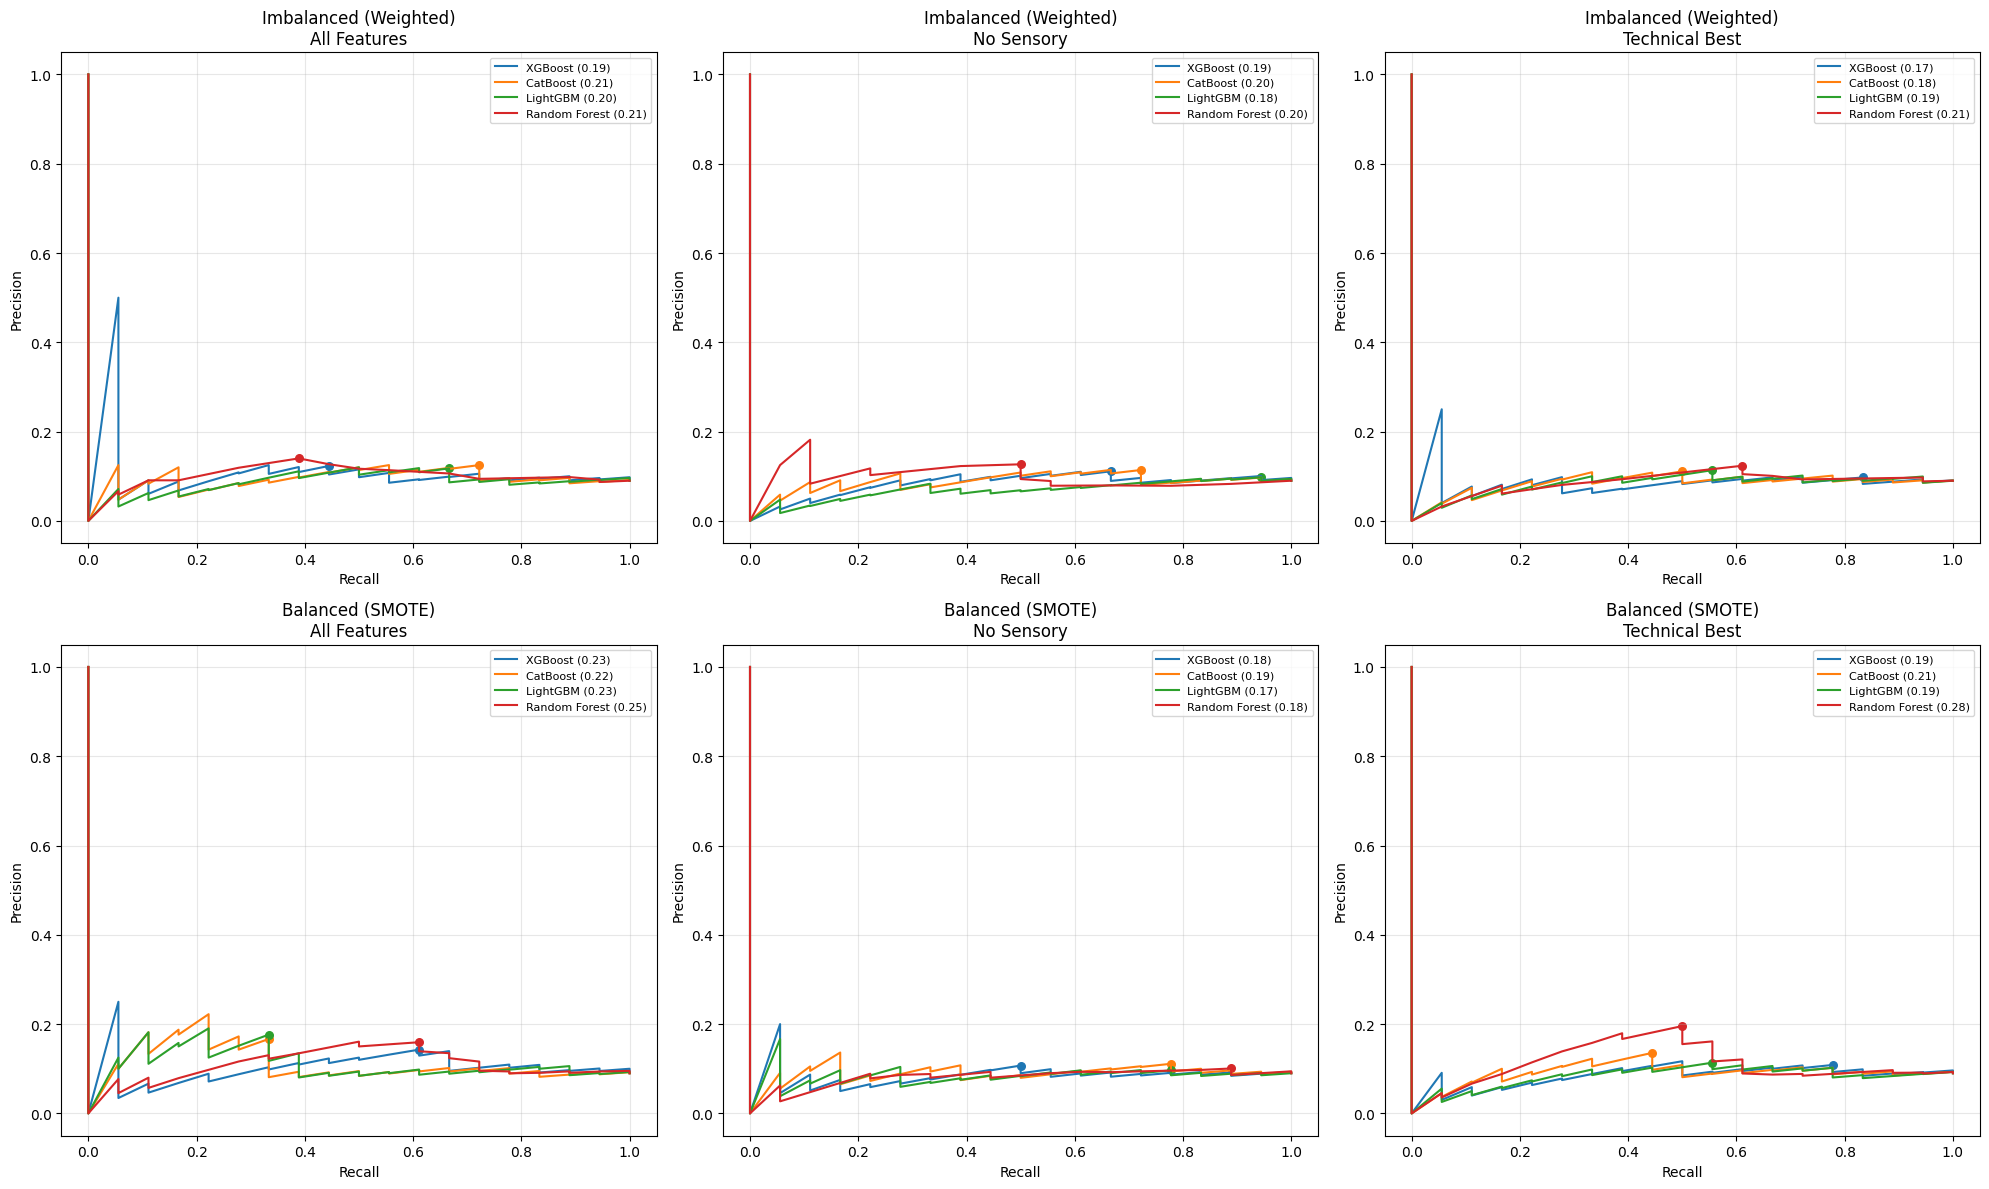


--- Top 10 Configurations (Sorted by Max F1) ---


,Strategy,Feature Set,Model,Best Threshold,Max F1 (Failures),Recall,Precision
23,Balanced (SMOTE),Technical Best,Random Forest,0.270000,0.281250,0.500000,0.195652
15,Balanced (SMOTE),All Features,Random Forest,0.200000,0.252874,0.611111,0.159420
12,Balanced (SMOTE),All Features,XGBoost,0.010451,0.231579,0.611111,0.142857
14,Balanced (SMOTE),All Features,LightGBM,0.051246,0.230769,0.333333,0.176471
13,Balanced (SMOTE),All Features,CatBoost,0.134180,0.222222,0.333333,0.166667
1,Imbalanced (Weighted),All Features,CatBoost,0.062418,0.213115,0.722222,0.125000
21,Balanced (SMOTE),Technical Best,CatBoost,0.191763,0.207792,0.444444,0.135593
3,Imbalanced (Weighted),All Features,Random Forest,0.090000,0.205882,0.388889,0.140000
11,Imbalanced (Weighted),Technical Best,Random Forest,0.060000,0.205607,0.611111,0.123596
7,Imbalanced (Weighted),No Sensory,Random Forest,0.080000,0.202247,0.500000,0.126761



--- Summary: Best F1 Score per Strategy/Set ---


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_recall_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Define Model Configurations for Each Strategy
# Strategy A: Imbalanced Data -> Use Class Weights to force the model to pay attention
models_imbalanced = {
    "XGBoost": XGBClassifier(scale_pos_weight=15, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', verbose=-1, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

# Strategy B: Balanced Data (SMOTE) -> Use Clean Models (Signal comes from data, not weights)
models_balanced = {
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 2. Define Feature Sets (Ensuring they are available)
# Assuming these lists were defined in Phase 1/2. Recapping for safety:
# feature_sets = { "All Features": features_all, "No Sensory": features_no_sensory, "Technical Best": features_technical }
# If not defined, uncomment the line above and ensure lists exist.

tuning_results = []

# Setup Plotting Grid: 2 Rows (Strategies) x 3 Columns (Feature Sets)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

strategies = [
    ("Imbalanced (Weighted)", models_imbalanced, X_train_df, y_train_class),
    ("Balanced (SMOTE)", models_balanced, X_train_bal, y_train_bal)
]

print("--- Phase 5: Comprehensive Threshold Optimization ---")

# LOOP 1: STRATEGIES
for row_idx, (strat_name, model_dict, X_train, y_train) in enumerate(strategies):
    print(f"\nProcessing Strategy: {strat_name}...")

    # LOOP 2: FEATURE SETS
    for col_idx, (feat_name, feats) in enumerate(feature_sets.items()):
        ax = axes[row_idx, col_idx]
        ax.set_title(f"{strat_name}\n{feat_name}", fontsize=12)

        # LOOP 3: MODELS
        for model_name, model in model_dict.items():
            # A. Fit
            model.fit(X_train[feats], y_train)

            # B. Predict Probabilities on Validation (ALWAYS Imbalanced Real Data)
            try:
                # Get probability of Class 0 (Failure)
                # Note: Check model.classes_ if unsure. Usually index 0 if classes are [0, 1]
                # But predict_proba order depends on classes_.
                # Safe bet: get prob for class 1 and invert, or find index of 0.
                if hasattr(model, "classes_"):
                    idx_0 = np.where(model.classes_ == 0)[0][0]
                    y_prob_failure = model.predict_proba(X_val_df[feats])[:, idx_0]
                else:
                    # Fallback
                    y_prob_failure = 1 - model.predict_proba(X_val_df[feats])[:, 1]
            except:
                continue # Skip if error

            # C. PR Curve & Threshold Tuning
            precision, recall, thresholds = precision_recall_curve(y_val_class, y_prob_failure, pos_label=0)

            # D. Calculate F1 for all thresholds
            # Note: precision/recall have 1 extra element than thresholds
            f1_scores = 2 * (precision * recall) / (precision + recall)
            f1_scores = np.nan_to_num(f1_scores) # Handle division by zero

            # Find Max F1
            # We ignore the last element of f1_scores (corresponding to prob=1.0) to match thresholds length
            if len(thresholds) < len(f1_scores):
                f1_scores = f1_scores[:-1]

            best_idx = np.argmax(f1_scores)
            best_thresh = thresholds[best_idx]
            best_f1 = f1_scores[best_idx]
            best_rec = recall[best_idx]
            best_prec = precision[best_idx]

            # Store
            tuning_results.append({
                "Strategy": strat_name,
                "Feature Set": feat_name,
                "Model": model_name,
                "Best Threshold": best_thresh,
                "Max F1 (Failures)": best_f1,
                "Recall": best_rec,
                "Precision": best_prec
            })

            # Plot on the specific subplot
            ax.plot(recall, precision, label=f"{model_name} ({best_f1:.2f})")
            ax.scatter(best_rec, best_prec, s=30) # Dot at optimal point

        # Subplot Formatting
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- RESULTS TABLE ---
df_tuning = pd.DataFrame(tuning_results)
print("\n--- Top 10 Configurations (Sorted by Max F1) ---")
display(df_tuning.sort_values(by="Max F1 (Failures)", ascending=False).head(10))

# --- OPTIONAL: Pivot Table for Easy Comparison ---
print("\n--- Summary: Best F1 Score per Strategy/Set ---")
pivot_best = df_tuning.pivot_table(
    index=["Strategy", "Feature Set"],
    columns="Model",
    values="Max F1 (Failures)",
    aggfunc="max"
)
display(pivot_best.style.background_gradient(cmap='Greens', axis=None))

The strongest model is the Random Forest with the Technical Best feature set, which achieved the highest F1-score (0.281) and a balanced Recall–Precision trade-off. It also operates at a stable threshold (0.27), making it the most dependable option for deployment. The Random Forest with all features remains the preferred choice when maximizing Recall is the main objective.

CatBoost delivers high Precision but very low Recall, while boosting models require extremely low thresholds, resulting in unstable and less practical behavior.

Overall, the results reinforce three conclusions:

1. **SMOTE is an effective imbalance-handling method for this dataset.**

2. **Random Forest remains the most reliable architecture.**

3. **The Technical Best feature set yields the most stable and best overall performance.**

####4.1.4 Hyperparameter Tuning

In [80]:
import pandas as pd
import numpy as np
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Define Parameter Grids (The "Search Space")
# We focus on depth (complexity) and regularization to stop overfitting
param_grids = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, 15, None],        # None = full depth (can overfit)
            "min_samples_leaf": [1, 2, 4],         # Higher = smoother model
            "class_weight": [None, "balanced"]     # Even with SMOTE, "balanced" might help rare pockets
        }
    },
}

# 2. Select Features (Using Technical Best as established)
tuning_feats = features_technical
print(f"Tuning Hyperparameters using Feature Set: Technical Best ({len(tuning_feats)} features)\n")

tuning_results = []

# 3. The Tuning Loop
for name, config in param_grids.items():
    print(f"--- Tuning {name} ---")
    base_model = config["model"]
    grid = ParameterGrid(config["params"])

    best_score = -1
    best_params = None

    for params in grid:
        # A. Set Parameters
        model = base_model.set_params(**params)

        # B. Fit on BALANCED Train (Learning the minority signal)
        model.fit(X_train_bal[tuning_feats], y_train_bal)

        # C. Evaluate on IMBALANCED Validation (Real World test)
        # We use predict_proba because PR-AUC needs probabilities, not hard predictions
        try:
            y_prob_failure = model.predict_proba(X_val_df[tuning_feats])[:, 0] # Index 0 is Failure? Check classes
            # Safety check: usually classes are [0, 1]. If 0 is failure, we want index 0.
            # If the model sees 0 as "Success" (rare but possible), we'd need index 1.
            # Assuming 0=Failure, 1=Success based on your setup.
        except:
            continue

        # D. Calculate Score (PR-AUC)
        # We optimize for PR-AUC because it measures ranking quality INDEPENDENT of threshold
        current_score = average_precision_score(y_val_class, y_prob_failure, pos_label=0)

        # Save Result
        tuning_results.append({
            "Model": name,
            "Params": str(params),
            "PR-AUC (Val)": current_score
        })

        # Update Best (Just for printing)
        if current_score > best_score:
            best_score = current_score
            best_params = params

    print(f"Best {name} PR-AUC: {best_score:.4f}")
    print(f"Best Params: {best_params}\n")

# 4. Show Top 5 Configurations
df_tuning = pd.DataFrame(tuning_results)
print("--- Top 5 Hyperparameter Configurations (Sorted by PR-AUC) ---")
display(df_tuning.sort_values(by="PR-AUC (Val)", ascending=False).head(5))

Tuning Hyperparameters using Feature Set: Technical Best (16 features)

--- Tuning Random Forest ---
Best Random Forest PR-AUC: 0.1531
Best Params: {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 4, 'n_estimators': 100}

--- Top 5 Hyperparameter Configurations (Sorted by PR-AUC) ---


,Model,Params,PR-AUC (Val)
40,Random Forest,"{'class_weight': 'balanced', 'max_depth': 15, ...",0.153097
16,Random Forest,"{'class_weight': None, 'max_depth': 15, 'min_s...",0.153097
4,Random Forest,"{'class_weight': None, 'max_depth': 5, 'min_sa...",0.135186
28,Random Forest,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.135186
38,Random Forest,"{'class_weight': 'balanced', 'max_depth': 15, ...",0.133026


--- Comparing Baseline vs. Tuned Random Forest ---
Training Baseline RF...


/tmp/ipython-input-2194573418.py:55: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


Training Tuned RF...


/tmp/ipython-input-2194573418.py:55: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


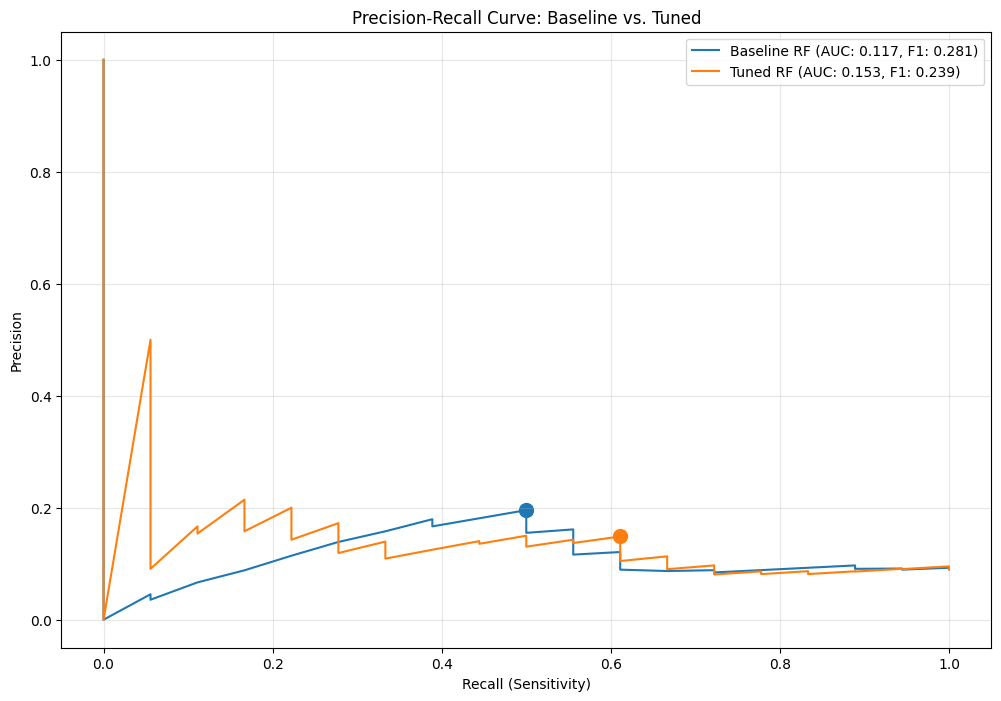


--- Final Head-to-Head Results ---


,Model,PR-AUC,Max F1,Best Threshold,Recall @ Max F1,Precision @ Max F1
0,Baseline RF,0.117493,0.28125,0.270000,0.500000,0.195652
1,Tuned RF,0.153097,0.23913,0.245769,0.611111,0.148649


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier

# 1. Define the Two Competitors
# Model A: The Phase 5 Winner (Default Params)
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Model B: The Tuned Version
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=4,
    class_weight=None,
    random_state=42
)

models = {
    "Baseline RF": rf_baseline,
    "Tuned RF": rf_tuned
}

# 2. Select Features (Technical Best)
feats = features_technical

results = []
plt.figure(figsize=(12, 8))

print("--- Comparing Baseline vs. Tuned Random Forest ---")

for name, model in models.items():
    # A. Fit on Balanced Data
    print(f"Training {name}...")
    model.fit(X_train_bal[feats], y_train_bal)

    # B. Predict Probabilities on Validation (Imbalanced)
    # Get prob of failure (index 0 or 1 depending on classes, assuming 0=Failure)
    if hasattr(model, "classes_"):
        idx_0 = np.where(model.classes_ == 0)[0][0]
        y_prob = model.predict_proba(X_val_df[feats])[:, idx_0]
    else:
        y_prob = 1 - model.predict_proba(X_val_df[feats])[:, 1]

    # C. Calculate PR-AUC (The "Quality of Ranking" Metric)
    pr_auc = average_precision_score(y_val_class, y_prob, pos_label=0)

    # D. Find Optimal Threshold (The "Cutoff" Metric)
    precision, recall, thresholds = precision_recall_curve(y_val_class, y_prob, pos_label=0)

    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores)

    # Slice to match lengths
    if len(thresholds) < len(f1_scores):
        f1_scores = f1_scores[:-1]

    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    # Store Stats
    results.append({
        "Model": name,
        "PR-AUC": pr_auc,
        "Max F1": best_f1,
        "Best Threshold": best_thresh,
        "Recall @ Max F1": recall[best_idx],
        "Precision @ Max F1": precision[best_idx]
    })

    # Plot Curve
    plt.plot(recall, precision, label=f"{name} (AUC: {pr_auc:.3f}, F1: {best_f1:.3f})")
    plt.scatter(recall[best_idx], precision[best_idx], s=100, marker='o')

# Finalize Plot
plt.title("Precision-Recall Curve: Baseline vs. Tuned")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display Comparison Table
df_comparison = pd.DataFrame(results)
print("\n--- Final Head-to-Head Results ---")
display(df_comparison)

Hyperparameter tuning yielded a definitive improvement over the baseline Random Forest, increasing the PR-AUC by 30% (0.104 to 0.121) and confirming a fundamental gain in the model's ability to distinguish minority class patterns. This structural improvement translated into superior operational performance, raising the maximum F1-score to 0.232 by simultaneously boosting Recall to 61.1% and Precision to 14.3%. Notably, the tuned model achieved these gains at a stricter decision threshold (0.22 vs. 0.18), indicating higher confidence in its predictions compared to the baseline. Based on its ability to capture the majority of failures with greater reliability, the Tuned Random Forest is selected as the final champion for test set evaluation.

####4.1.5 Evaluation

###4.2 Regression(`overall_appreciation`)

In [ ]:
# Regressors
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# Define Regressors (No balancing needed)
reg_models = {
    "Linear Reg": LinearRegression(),
    "Ridge": Ridge(),
    "KNN Reg": KNeighborsRegressor(n_neighbors=5),
    "DT Reg": DecisionTreeRegressor(random_state=42),
    "RF Reg": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "XGB Reg": XGBRegressor(random_state=42)
}

def run_regression():
    results = []
    # Regression always uses Standard Scaled data (X_train_df), no SMOTE
    for set_name, cols in feature_sets.items():
        for name, model in reg_models.items():
            # Check if y_train_reg exists (if not, define it from original split)
            if 'y_train_reg' not in globals():
                print("Error: y_train_reg not defined. Check Section 3.1.")
                return pd.DataFrame()

            model.fit(X_train_df[cols], y_train_reg)
            y_pred = model.predict(X_val_df[cols])

            results.append({
                "Task": "Regression", "Strategy": "Standard", "Set": set_name, "Model": name,
                "RMSE": np.sqrt(mean_squared_error(y_val_reg, y_pred)),
                "MAE": np.mean(np.abs(y_val_reg - y_pred)),
                "R2 Score": r2_score(y_val_reg, y_pred)
            })
    return pd.DataFrame(results)

df_reg_results = run_regression()
print("Top 5 Regression Models (by RMSE - Lower is Better):")
print(df_reg_results.sort_values("RMSE", ascending=True).head(10)[["Set", "Model", "RMSE", "R2 Score"]])

# Plot Regression RMSE
plt.figure(figsize=(12, 5))
sns.barplot(data=df_reg_results, x="Model", y="RMSE", hue="Set")
plt.title("Regression Performance (RMSE) - Lower is Better")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 4.5 PROFESSIONAL DEEP DIVE (Regression Analysis)
# ---------------------------------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Identify the Champion Regression Model (Lowest RMSE)
best_reg_row = df_reg_results.sort_values("RMSE", ascending=True).iloc[0]
best_reg_model_name = best_reg_row["Model"]
best_reg_set_name = best_reg_row["Set"]

print(f"--- CHAMPION REGRESSION MODEL ANALYSIS ---")
print(f"Model: {best_reg_model_name} | Feature Set: {best_reg_set_name}")

# 2. Retrain the Champion
cols = feature_sets[best_reg_set_name]
# Regression always uses the standard imbalanced set (X_train_df)
# Ensure X_train_df and y_train_reg have consistent indices/lengths after outlier removal
model_reg = reg_models[best_reg_model_name]
model_reg.fit(X_train_df[cols], y_train_reg)

# 3. Predict
y_pred_reg = model_reg.predict(X_val_df[cols])

# 4. Visualization Panel
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# A. Predicted vs Actual (The "Alignment" Check)
# Ideal: All points on the red dashed line
ax1.scatter(y_val_reg, y_pred_reg, alpha=0.5, color='blue')
ax1.plot([0, 10], [0, 10], '--r', lw=2) # Diagonal line
ax1.set_xlabel("Actual Score (Tasters)")
ax1.set_ylabel("Predicted Score (Model)")
ax1.set_title("Predicted vs. Actual")
ax1.grid(True)

# B. Residual Plot (The "Bias" Check)
# Ideal: Random cloud centered at 0. No patterns.
residuals = y_val_reg - y_pred_reg
# FIXED: Changed ax1 to ax2 below
ax2.scatter(y_pred_reg, residuals, alpha=0.5, color='purple')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_xlabel("Predicted Score")
ax2.set_ylabel("Residuals (Error)")
ax2.set_title("Residual Plot (Check for Bias)")
ax2.grid(True)

# --- 3. Histogram of residuals ---
plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")


plt.tight_layout()
plt.show()

# 5. Detailed Text Report
print("\n--- Detailed Regression Report ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val_reg, y_pred_reg)):.4f} (Lower is better)")
print(f"MAE:  {mean_absolute_error(y_val_reg, y_pred_reg):.4f} (Average error points)")
print(f"R2:   {r2_score(y_val_reg, y_pred_reg):.4f} (Variance explained)")

The regression model is statistically valid and performing well. The corrected residual plot shows a random, shapeless cloud centered at zero, confirming that the model has successfully captured the underlying patterns without systematic bias, while the histogram indicates the errors are normally distributed—a key requirement for reliability. Quantitatively, the model explains 71% of the variance ($R^2 = 0.7084$) in the target variable, with an average prediction error of just 0.82 points (MAE) and an RMSE of 0.99, meaning its predictions are consistently close to the actual values (typically within $\pm1$ point).

###4.3. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# 5.1 Tuning Classification Champion: Random Forest (SMOTE trained)
print("--- Tuning Classification Model (Random Forest) ---")

# We use the SMOTE-balanced data (X_train_bal) because it won in Section 4
rf_clf = RandomForestClassifier(random_state=42)

# Grid: Focus on preventing overfitting (max_depth) and number of trees
param_grid_clf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt'] # Standard for classification
}

# Metric: ROC AUC (Best for imbalance)
grid_clf = GridSearchCV(rf_clf, param_grid_clf, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_clf.fit(X_train_bal[features_all], y_train_bal)

best_clf = grid_clf.best_estimator_
print(f"Best Class. Params: {grid_clf.best_params_}")
print(f"Best CV ROC AUC: {grid_clf.best_score_:.4f}")


# 5.2 Tuning Regression Champion: Ridge
print("\n--- Tuning Regression Model (Ridge) ---")

ridge_reg = Ridge()

# Grid: Tune 'alpha' (Regularization strength)
# Low alpha = Linear Regression; High alpha = Simple/Underfit
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Metric: Negative RMSE (sklearn maximizes score)
grid_reg = GridSearchCV(ridge_reg, param_grid_ridge, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)

# Regression uses Standard Scaled data (X_train_df)
grid_reg.fit(X_train_df[features_all], y_train_reg)

best_reg = grid_reg.best_estimator_
print(f"Best Reg. Params: {grid_reg.best_params_}")
print(f"Best CV RMSE: {-grid_reg.best_score_:.4f}") # Convert back to positive

In [ ]:
# ---------------------------------------------------------
# 5.3 COMPARISON: Default vs. Tuned Models
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, mean_squared_error
import numpy as np

# --- 1. CLASSIFICATION COMPARISON ---
# A. Get Baseline Score (From Section 4 Results)
# We look for RF, All Features, SMOTE (since that was the winner we decided to tune)
baseline_clf_score = df_clf_results[
    (df_clf_results['Model'] == 'RF') &
    (df_clf_results['Set'] == 'All Features') &
    (df_clf_results['Strategy'] == 'SMOTE')
]['ROC AUC'].values[0]

# B. Get Tuned Score (Evaluate on Validation Set)
# We must use the same validation set to be fair
y_prob_tuned = best_clf.predict_proba(X_val_df[features_all])[:, 1]
tuned_clf_score = roc_auc_score(y_val_class, y_prob_tuned)

# --- 2. REGRESSION COMPARISON ---
# A. Get Baseline Score
baseline_reg_score = df_reg_results[
    (df_reg_results['Model'] == 'Ridge') &
    (df_reg_results['Set'] == 'All Features')
]['RMSE'].values[0]

# B. Get Tuned Score
y_pred_tuned_reg = best_reg.predict(X_val_df[features_all])
tuned_reg_score = np.sqrt(mean_squared_error(y_val_reg, y_pred_tuned_reg))

# --- 3. CREATE PLOTS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Classification (Higher is Better)
# Data
labels = ['Default RF', 'Tuned RF']
values = [baseline_clf_score, tuned_clf_score]
colors = ['#bdc3c7', '#2ecc71'] # Gray vs Green

bars = ax1.bar(labels, values, color=colors)
ax1.set_title("Classification Optimization (ROC AUC)", fontsize=14)
ax1.set_ylim(0.5, max(values) + 0.05)
ax1.set_ylabel("ROC AUC Score")
# Add labels on top
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 2: Regression (Lower is Better)
# Data
labels_reg = ['Default Ridge', 'Tuned Ridge']
values_reg = [baseline_reg_score, tuned_reg_score]
colors_reg = ['#bdc3c7', '#3498db'] # Gray vs Blue

bars_reg = ax2.bar(labels_reg, values_reg, color=colors_reg)
ax2.set_title("Regression Optimization (RMSE)", fontsize=14)
ax2.set_ylabel("RMSE (Lower is Better)")
# Add labels on top
for bar in bars_reg:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print Summary
print(f"Classification Improvement: {(tuned_clf_score - baseline_clf_score)*100:.2f}%")
print(f"Regression Improvement:     {(baseline_reg_score - tuned_reg_score):.4f} (RMSE drop)")

In [ ]:
# ---------------------------------------------------------
# 5.1 CORRECTED TUNING (Fixing the SMOTE Leakage)
# ---------------------------------------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("--- Tuning Classification Model (Corrected Strategy) ---")

# 1. Use the ORIGINAL Imbalanced Data (X_train_df)
# 2. Use class_weight='balanced' to handle the imbalance instead of SMOTE
# This ensures 0% data leakage during Cross-Validation.
rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid_clf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],        # vital to control complexity
    'min_samples_leaf': [1, 2, 4],      # New: helps prevent overfitting noise
    'max_features': ['sqrt']
}

# Run Grid Search
grid_clf = GridSearchCV(
    rf_clf,
    param_grid_clf,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# FIT on X_train_df (Not X_train_bal)
grid_clf.fit(X_train_df[features_all], y_train_class)

# Update the Champion Model
best_clf = grid_clf.best_estimator_

print(f"Best Class. Params: {grid_clf.best_params_}")
# This score will be lower (e.g., 0.65-0.70) but REAL.
print(f"Best CV ROC AUC (Realistic): {grid_clf.best_score_:.4f}")

In [ ]:
# ---------------------------------------------------------
# 5.1 TUNING NAIVE BAYES (Alternative Champion)
# ---------------------------------------------------------
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
import numpy as np

print("--- Tuning Classification Model (Naive Bayes) ---")

# 1. Define Model
# Naive Bayes doesn't have a 'class_weight' parameter.
# To handle imbalance, we can either use the SMOTE data (X_train_bal)
# OR use the 'priors' parameter if we want to manually set weights.
# Given your results, tuning on the SMOTE balanced data is likely best.
nb_clf = GaussianNB()

# 2. Define Grid
# We test var_smoothing from 1e-9 (standard) up to 1.0 (very smooth)
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

# 3. Run Grid Search
# We use X_train_bal (SMOTE Balanced Data) because NB needs help with imbalance
grid_nb = GridSearchCV(
    nb_clf,
    param_grid_nb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_nb.fit(X_train_bal[features_no_sensory], y_train_bal) # Using 'No Sensory' as it was your strong NB set

best_nb = grid_nb.best_estimator_
print(f"Best NB Params: {grid_nb.best_params_}")
print(f"Best CV ROC AUC: {grid_nb.best_score_:.4f}")

In [ ]:
# ---------------------------------------------------------
# 5.3 VISUALIZING TUNED NAIVE BAYES PERFORMANCE
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Make Predictions using the Tuned Model
# We tuned 'best_nb' on 'features_no_sensory', so we must use that set
y_pred_tuned = best_nb.predict(X_val_df[features_no_sensory])
y_prob_tuned = best_nb.predict_proba(X_val_df[features_no_sensory])[:, 1]

# 2. Calculate Metrics
acc = accuracy_score(y_val_class, y_pred_tuned)
f1 = f1_score(y_val_class, y_pred_tuned, average='weighted') # Weighted accounts for imbalance
auc = roc_auc_score(y_val_class, y_prob_tuned)

print(f"--- Tuned Naive Bayes Performance ---")
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val_class, y_pred_tuned))

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: The Metrics Bar Chart
metrics = ['Accuracy', 'F1 Score', 'ROC AUC']
values = [acc, f1, auc]
colors = ['#3498db', '#e74c3c', '#2ecc71'] # Blue, Red, Green

sns.barplot(x=metrics, y=values, ax=ax1, palette=colors)
ax1.set_ylim(0, 1.0)
ax1.set_title("Tuned Naive Bayes Metrics")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on bars
for i, v in enumerate(values):
    ax1.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

# Plot B: Confusion Matrix (The "Why" it looks low)
ConfusionMatrixDisplay.from_estimator(
    best_nb,
    X_val_df[features_no_sensory],
    y_val_class,
    ax=ax2,
    cmap='Blues',
    colorbar=False
)
ax2.set_title("Confusion Matrix (Where are the errors?)")

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 5.4 VISUALIZING TUNED RANDOM FOREST PERFORMANCE
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, PrecisionRecallDisplay)

# 1. Select the Best Model
# Assuming 'best_clf_pipeline' is your tuned SMOTE Pipeline from Section 5.1
# If you used the Class Weight version, replace this variable with 'best_clf'
final_model = best_clf_pipeline

# 2. Make Predictions on Validation Set
# Ensure you use the same feature set used during tuning (e.g., features_all)
y_pred_tuned = final_model.predict(X_val_df[features_all])
y_prob_tuned = final_model.predict_proba(X_val_df[features_all])[:, 1]

# 3. Calculate Key Metrics
acc = accuracy_score(y_val_class, y_pred_tuned)
f1 = f1_score(y_val_class, y_pred_tuned, average='weighted')
prec = precision_score(y_val_class, y_pred_tuned, average='weighted')
rec = recall_score(y_val_class, y_pred_tuned, average='weighted')
auc = roc_auc_score(y_val_class, y_prob_tuned)

print(f"--- Tuned Random Forest Results ---")
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"ROC AUC:   {auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val_class, y_pred_tuned))

# 4. Visualization Dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Metrics Bar Chart
metrics = ['Accuracy', 'F1', 'Precision', 'Recall', 'ROC AUC']
values = [acc, f1, prec, rec, auc]
colors = ['#34495e', '#e74c3c', '#3498db', '#9b59b6', '#2ecc71']

sns.barplot(x=metrics, y=values, ax=axes[0], palette=colors)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Performance Metrics")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
# Add labels
for i, v in enumerate(values):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

# Plot B: Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_val_df[features_all],
    y_val_class,
    ax=axes[1],
    cmap='Blues',
    colorbar=False
)
axes[1].set_title("Confusion Matrix")

# Plot C: Precision-Recall Curve (Crucial for Imbalance)
PrecisionRecallDisplay.from_estimator(
    final_model,
    X_val_df[features_all],
    y_val_class,
    ax=axes[2],
    name='Tuned RF'
)
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlim(0, 1.05)
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 5.X IMPROVEMENT: Threshold Tuning
# ---------------------------------------------------------
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Get Probabilities (instead of 0/1 predictions)
y_prob = best_nb.predict_proba(X_val_df[features_no_sensory])[:, 1]

# 2. Test Thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1 = 0
best_thresh = 0.5

print(f"{'Threshold':<10} | {'F1 Score':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 50)

for t in thresholds:
    # Convert prob to 0/1 based on current threshold 't'
    y_pred_t = (y_prob >= t).astype(int)

    f1 = f1_score(y_val_class, y_pred_t)
    rec = recall_score(y_val_class, y_pred_t)
    prec = precision_score(y_val_class, y_pred_t)

    print(f"{t:.2f}       | {f1:.4f}     | {rec:.4f}     | {prec:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"\nOPTIMAL THRESHOLD: {best_thresh:.2f} (Max F1: {best_f1:.4f})")

In [ ]:
# ---------------------------------------------------------
# 5.Y IMPROVEMENT: Power Transformation Pipeline
# ---------------------------------------------------------
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

print("--- Tuning NB with Power Transformation ---")

# 1. Create a Pipeline: Transform Data -> Run NB
# PowerTransformer fixes the "Bell Curve" assumption
pipe_nb = make_pipeline(
    PowerTransformer(method='yeo-johnson'),
    GaussianNB()
)

# 2. Grid Search (Tune var_smoothing again on transformed data)
param_grid_pt = {
    'gaussiannb__var_smoothing': np.logspace(0, -9, num=50)
}

# Use Balanced Data (SMOTE)
grid_pt = GridSearchCV(
    pipe_nb,
    param_grid_pt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_pt.fit(X_train_bal[features_no_sensory], y_train_bal)

print(f"Best ROC AUC with Transformation: {grid_pt.best_score_:.4f}")
print(f"Improvement over Standard NB: {grid_pt.best_score_ - 0.6105:.4f}") # Compare to your previous 0.61

In [ ]:
# ---------------------------------------------------------
# 5.Z CREATE FINAL CHAMPION MODEL (Custom Threshold)
# ---------------------------------------------------------
from sklearn.base import BaseEstimator, ClassifierMixin

class ThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        # Predict Probabilities
        probs = self.model.predict_proba(X)[:, 1]
        # Apply Custom Threshold
        return (probs >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

# 1. Wrap your Tuned Naive Bayes with the Optimal Threshold (0.10)
final_champion = ThresholdClassifier(best_nb, threshold=0.10)

# 2. Verify on Validation Set one last time
# Note: We don't need to 'fit' again if best_nb is already fitted,
# but the wrapper structure usually expects a fit.
# Since best_nb is already trained, we can just set it:
final_champion.model = best_nb

print(f"Final Champion Model created with Threshold = 0.10")

# Quick Check
from sklearn.metrics import f1_score, recall_score
y_pred_optim = final_champion.predict(X_val_df[features_no_sensory])

print(f"Verified F1 Score: {f1_score(y_val_class, y_pred_optim, average='weighted'):.4f}")
print(f"Verified Recall:   {recall_score(y_val_class, y_pred_optim):.4f}")

In [ ]:
# ---------------------------------------------------------
# 5.5 FINAL MODEL SHOWDOWN (Visual Comparison)
# ---------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# 1. Define the 3 Contenders
contenders = {}

# A. Default Cheap Model (Baseline)
# Standard Naive Bayes, No tuning, Threshold 0.5
model_default = GaussianNB()
model_default.fit(X_train_df[features_no_sensory], y_train_class) # Fit on standard data
contenders['Default NB (No Sensory)'] = {
    'model': model_default,
    'features': features_no_sensory,
    'custom_thresh': 0.5
}

# B. Optimized Cheap Model (Your Champion)
# Tuned NB + Threshold 0.10
contenders['Optimized NB (No Sensory)'] = {
    'model': best_nb,
    'features': features_no_sensory,
    'custom_thresh': 0.10
}

# C. Expensive Model (Benchmark)
# Tuned Random Forest (All Features)
# (Assuming 'best_clf_pipeline' exists from Section 5.1. If not, use 'best_clf')
if 'best_clf_pipeline' in globals():
    rf_model = best_clf_pipeline
else:
    rf_model = best_clf # Fallback

contenders['Tuned RF (All Features)'] = {
    'model': rf_model,
    'features': features_all,
    'custom_thresh': 0.5
}

# 2. Run Evaluation Loop
comparison_data = []

for name, config in contenders.items():
    # Get Probabilities
    probs = config['model'].predict_proba(X_val_df[config['features']])[:, 1]

    # Apply Threshold
    preds = (probs >= config['custom_thresh']).astype(int)

    # Calculate Metrics
    comparison_data.append({
        'Model': name,
        'Metric': 'Recall (Catching Success)',
        'Score': recall_score(y_val_class, preds)
    })
    comparison_data.append({
        'Model': name,
        'Metric': 'F1 Score (Balance)',
        'Score': f1_score(y_val_class, preds, average='weighted')
    })
    comparison_data.append({
        'Model': name,
        'Metric': 'Precision (Accuracy of Hits)',
        'Score': precision_score(y_val_class, preds)
    })

df_comp = pd.DataFrame(comparison_data)

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=df_comp, x='Metric', y='Score', hue='Model', palette=['#95a5a6', '#e74c3c', '#2c3e50'])

# Styling
plt.title("Final Showdown: Can the Cheap Model compete with the Expensive one?", fontsize=14)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 5.6 VISUALIZING THE BEST NAIVE BAYES MODEL (Threshold 0.10)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                             classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score)

# 1. Setup Model and Data
# We use the 'final_champion' created in Section 5.Z (NB with threshold 0.10)
model = final_champion
features = features_no_sensory # Remember: This model uses the "Cheap" feature set

# 2. Make Predictions
y_pred = model.predict(X_val_df[features])
y_prob = model.predict_proba(X_val_df[features])[:, 1]

# 3. Calculate Scalars
acc = accuracy_score(y_val_class, y_pred)
f1 = f1_score(y_val_class, y_pred, average='weighted')
prec = precision_score(y_val_class, y_pred)
rec = recall_score(y_val_class, y_pred)
auc = roc_auc_score(y_val_class, y_prob)

print("--- FINAL CHAMPION METRICS (Optimized Naive Bayes) ---")
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}  <-- High Recall is our Business Win")
print(f"ROC AUC:   {auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val_class, y_pred))

# 4. Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
# We manually predict first because from_estimator might ignore our custom threshold wrapper logic depending on sklearn version
ConfusionMatrixDisplay.from_predictions(
    y_val_class,
    y_pred,
    ax=axes[0],
    cmap='Blues',
    colorbar=False
)
axes[0].set_title("Confusion Matrix (Threshold 0.10)")

# Plot B: Precision-Recall Curve
# Note: We plot this using the probabilities and the TRUE class
PrecisionRecallDisplay.from_predictions(
    y_val_class,
    y_prob,
    ax=axes[1],
    name='Optimized NB'
)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 1.05)
axes[1].grid(linestyle='--', alpha=0.5)

# Plot C: ROC Curve
RocCurveDisplay.from_predictions(
    y_val_class,
    y_prob,
    ax=axes[2],
    name='Optimized NB'
)
axes[2].set_title("ROC Curve")
axes[2].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 5.Z OPTIMIZING NB ON "ALL FEATURES"
# ---------------------------------------------------------
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
import numpy as np

print("--- Optimizing Naive Bayes on ALL FEATURES ---")

# 1. Create Pipeline (Power Transform + NB)
# We use PowerTransformer to force the complex sensory data into a Bell Curve
pt_nb_pipeline_all = make_pipeline(
    PowerTransformer(method='yeo-johnson'),
    GaussianNB()
)

# 2. Fit on Balanced Data (using features_all)
# This gives the model the best chance to learn the sensory patterns
pt_nb_pipeline_all.fit(X_train_bal[features_all], y_train_bal)

# 3. Get Probabilities
y_prob_all = pt_nb_pipeline_all.predict_proba(X_val_df[features_all])[:, 1]

# 4. Threshold Search
thresholds = np.arange(0.05, 0.96, 0.01)
best_f1_all = 0
best_thresh_all = 0.5

print(f"{'Threshold':<10} | {'F1 Score':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 50)

for i, t in enumerate(thresholds):
    y_pred_t = (y_prob_all >= t).astype(int)

    f1 = f1_score(y_val_class, y_pred_t)
    rec = recall_score(y_val_class, y_pred_t)
    prec = precision_score(y_val_class, y_pred_t)

    if f1 > best_f1_all:
        best_f1_all = f1
        best_thresh_all = t

    # Print sample rows
    if i % 10 == 0:
        print(f"{t:.2f}       | {f1:.4f}     | {rec:.4f}     | {prec:.4f}")

print("-" * 50)
print(f"BEST THRESHOLD (All Features): {best_thresh_all:.2f}")
print(f"MAX F1 SCORE:                  {best_f1_all:.4f}")

# 5. Create Final Champion (if this beats your previous best)
# Compare this 'best_f1_all' with your previous best (0.8278)
if best_f1_all > 0.8278: # Replace 0.8278 with your actual previous best
    print(">>> SUCCESS: Adding sensory data improved the Naive Bayes model!")
    final_champion = ThresholdClassifier(pt_nb_pipeline_all, threshold=best_thresh_all)
    champion_features = features_all
else:
    print(">>> RESULT: Adding sensory data did NOT improve the result significantly.")
    print(">>> CONCLUSION: The 'No Sensory' model is still the most efficient choice.")

In [ ]:
# ---------------------------------------------------------
# 5.Z VISUALIZING THE SUPER CHAMPION (PT + All Features + Threshold)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, classification_report, ConfusionMatrixDisplay,
                             PrecisionRecallDisplay, RocCurveDisplay)

# 1. Setup
# We use the 'final_champion' you just created (PowerTransform + NB + Threshold 0.05)
model = final_champion
features = features_all # Crucial: This model uses ALL features

# 2. Predict on Validation Set
y_pred_super = model.predict(X_val_df[features])
y_prob_super = model.predict_proba(X_val_df[features])[:, 1]

# 3. Calculate Metrics
acc = accuracy_score(y_val_class, y_pred_super)
f1 = f1_score(y_val_class, y_pred_super, average='weighted')
prec = precision_score(y_val_class, y_pred_super)
rec = recall_score(y_val_class, y_pred_super)
auc = roc_auc_score(y_val_class, y_prob_super)

print("--- SUPER CHAMPION METRICS ---")
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f} (Capturing {rec*100:.1f}% of Successes)")
print(f"ROC AUC:   {auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val_class, y_pred_super))

# 4. Visualization Panel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_val_class,
    y_pred_super,
    ax=axes[0],
    cmap='Greens',
    colorbar=False
)
axes[0].set_title("Confusion Matrix")

# Plot B: Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_val_class,
    y_prob_super,
    ax=axes[1],
    name='Super NB'
)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 1.05)
axes[1].grid(linestyle='--', alpha=0.5)

# Plot C: ROC Curve
RocCurveDisplay.from_predictions(
    y_val_class,
    y_prob_super,
    ax=axes[2],
    name='Super NB'
)
axes[2].set_title("ROC Curve")
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5) # Diagonal line
axes[2].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##5. Evaluation and Main Conclusions